# Tamweel Lite – All Five Labs (Combined)

**Author:** Shatha Alsubaie · SDA-DSC-211 · SDAIA Academy

This notebook gathers the five executed labs in one file for easy review. The individual notebooks `01`–`05` in this folder are the official ones used for running and checking.

**Contents**
1. Day 1 – Baseline & Boosting
2. Day 2 – Honest Validation & Tuning
3. Day 3 – Cost-Sensitive Decision
4. Day 4 – Explainability & Calibration
5. Day 5 – Final Model & Delivery

---
# Day 1 – Baseline & Boosting
*Source notebook: `01_baseline_boosting.ipynb`*

# Day 1 · Baseline and boosting comparison

In [1]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
LAB_REVISION = "c8344f6b19b26dcbce3dcfc671b746c59bf55895"
LAB_SHA256 = "2a968ba9e738cc5e3dae12077e576fdb40ec6ec64230613e445bbc7884e7e1ba"
fetch_verified(
    f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/scripts/day1_lab.py",
    ROOT / "scripts/day1_lab.py", LAB_SHA256)
print("Day 1 setup verified | إعداد اليوم الأول جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.15 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 1 setup verified | إعداد اليوم الأول جاهز


In [3]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import roc_curve, precision_recall_curve
from data_checks import load_course_data
from day1_lab import (LabConfig, MODEL_NAMES, make_splits, select_tree_count,
                      fit_model, compare_models, learner_checkpoint, config_dict)

warnings.filterwarnings("ignore", message="scipy.optimize:.*disp.*", category=DeprecationWarning)
frames, contract, data_summary = load_course_data(ROOT)
train = frames["train"]
FAST_MODE, FULL_MODE = True, False  # Choose exactly one mode.
assert FAST_MODE != FULL_MODE, "Choose exactly one mode."
config = LabConfig(max_trees=300 if FAST_MODE else 900)
X, y, splits = make_splits(train, contract, seed=config.seed)
ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
display(pd.DataFrame({"rows": [len(train)], "predictors": [X.shape[1]],
                      "positive_rate": [y.mean()], "missing_cells": [int(X.isna().sum().sum())]}))
display(train[["application_id", "income_sar", "bureau_score", contract["target"]["name"]]].head(3))

,rows,predictors,positive_rate,missing_cells
0,10000,22,0.0789,766


,application_id,income_sar,bureau_score,default_within_90d
0,TR-001121,8938.11,584.0,0
1,TR-002836,16995.65,652.0,0
2,TR-005579,8353.27,734.0,0


In [4]:
development, comparison = splits["development"], splits["comparison"]
inner_fit, inner_stop = splits["inner_fit"], splits["inner_stop"]
assert not (set(development) & set(comparison))
assert not (set(inner_fit) & set(inner_stop))
split_table = pd.DataFrame([
    {"role": role, "rows": len(index), "positive_rate": y.loc[index].mean()}
    for role, index in splits.items()
])
shared_customers = len(set(train.loc[development, "customer_id"]) & set(train.loc[comparison, "customer_id"]))
display(split_table)
print(f"Customers shared across development/comparison: {shared_customers} — revisit on Day 2")
models, timings, selections = {}, {}, {}

,role,rows,positive_rate
0,development,8000,0.078875
1,comparison,2000,0.079000
2,inner_fit,6000,0.078833
3,inner_stop,2000,0.079000


Customers shared across development/comparison: 1226 — revisit on Day 2


In [5]:
name = "Logistic Regression"
models[name], timings[name] = fit_model(name, X.loc[development], y.loc[development], config)
print(f"Baseline fitted on {len(development):,} rows in {timings[name]['train_seconds']:.3f} s")

Baseline fitted on 8,000 rows in 0.037 s


In [6]:
for name in ("XGBoost", "LightGBM"):
    selections[name] = select_tree_count(
        name, X.loc[inner_fit], y.loc[inner_fit], X.loc[inner_stop], y.loc[inner_stop], config)
    models[name], timings[name] = fit_model(
        name, X.loc[development], y.loc[development], config, selections[name])
    print(f"{name}: {selections[name]['selected_trees']} selected trees; "
          f"{selections[name]['rounds_evaluated']} evaluated rounds; "
          f"{timings[name]['train_seconds']:.3f} s including selection + refit")
    if selections[name]["hit_tree_budget"]:
        print("Tree budget reached: record this limitation before considering FULL_MODE.")

XGBoost: 61 selected trees; 91 evaluated rounds; 0.245 s including selection + refit
LightGBM: 41 selected trees; 71 evaluated rounds; 0.221 s including selection + refit


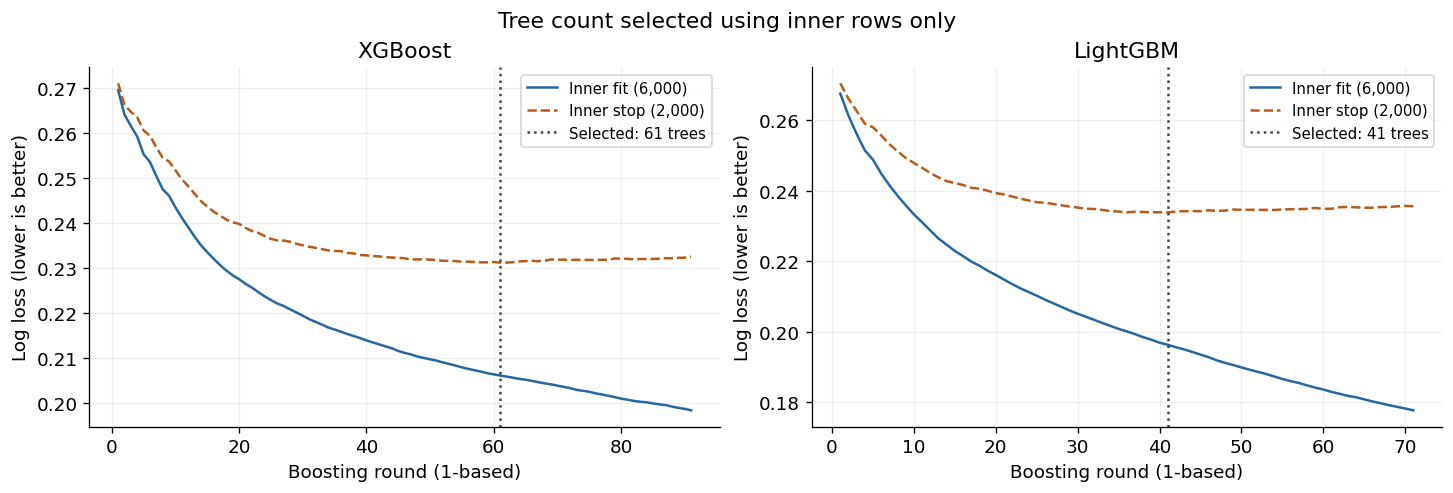

In [7]:
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})
colors = {"Logistic Regression": "#2667A0", "XGBoost": "#BA5A17", "LightGBM": "#18816A"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, (name, result) in zip(axes, selections.items()):
    rounds = np.arange(1, len(result["curves"]["fit"]) + 1)
    ax.plot(rounds, result["curves"]["fit"], label="Inner fit (6,000)", color="#2667A0")
    ax.plot(rounds, result["curves"]["stop"], label="Inner stop (2,000)", color="#BA5A17", linestyle="--")
    ax.axvline(result["selected_trees"], color="#444444", linestyle=":",
               label=f"Selected: {result['selected_trees']} trees")
    ax.set(title=name, xlabel="Boosting round (1-based)", ylabel="Log loss (lower is better)")
    ax.legend(fontsize=9)
fig.suptitle("Tree count selected using inner rows only")
fig.savefig(ARTIFACTS / "day1_learning_curves.png", dpi=160)
plt.show()

In [8]:
comparison_table, probabilities = compare_models(
    models, timings, selections, X.loc[comparison], y.loc[comparison])
comparison_table["selected_trees"] = comparison_table["selected_trees"].astype("Int64")
display(comparison_table[["model", "roc_auc", "average_precision", "train_seconds",
                          "selected_trees", "comparison_rows", "positive_rate"]].round(4))
comparison_table.to_csv(ARTIFACTS / "day1_model_comparison.csv", index=False)
prediction_export = train.loc[comparison, ["application_id", "default_within_90d"]].join(probabilities)
prediction_export.to_csv(ARTIFACTS / "day1_comparison_predictions.csv", index=False)
assert len(comparison_table) == 3
assert comparison_table[["roc_auc", "average_precision", "train_seconds"]].notna().all().all()
print("TECHNICAL_READY — three models compared; your interpretation is still required.")

,model,roc_auc,average_precision,train_seconds,selected_trees,comparison_rows,positive_rate
0,Logistic Regression,0.8213,0.3258,0.0375,<NA>,2000,0.079
1,XGBoost,0.8124,0.3338,0.2450,61,2000,0.079
2,LightGBM,0.8138,0.3248,0.2209,41,2000,0.079


TECHNICAL_READY — three models compared; your interpretation is still required.


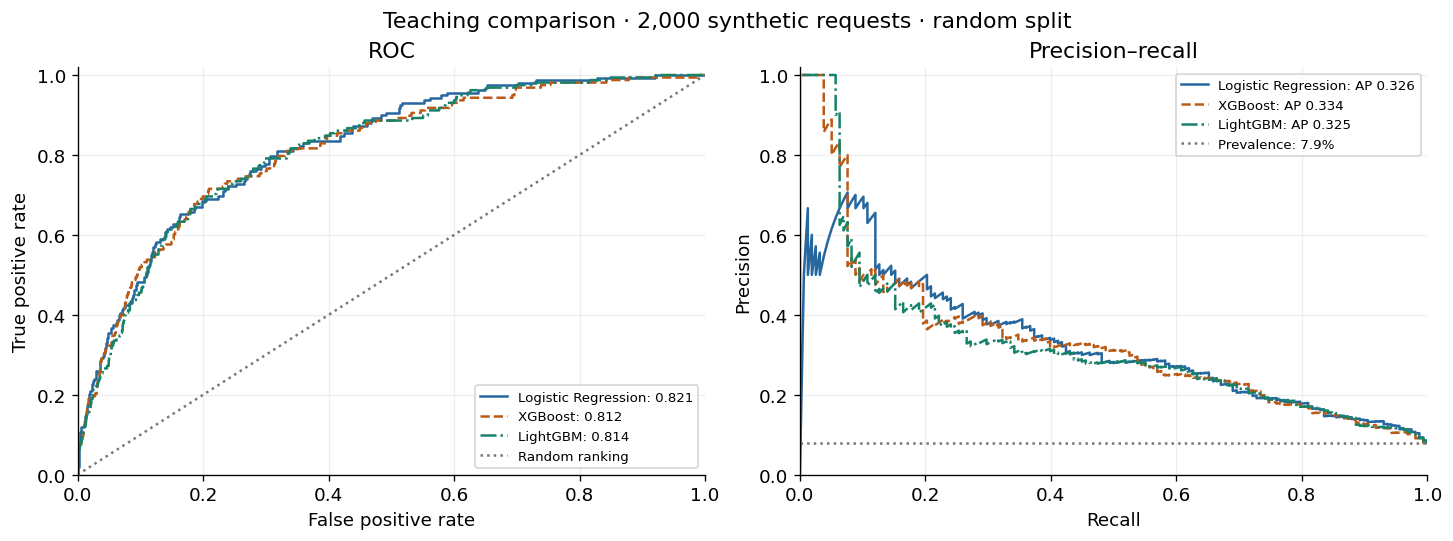

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
styles = ["-", "--", "-."]
for name, style in zip(MODEL_NAMES, styles):
    fpr, tpr, _ = roc_curve(y.loc[comparison], probabilities[name])
    precision, recall, _ = precision_recall_curve(y.loc[comparison], probabilities[name])
    row = comparison_table.set_index("model").loc[name]
    axes[0].plot(fpr, tpr, color=colors[name], linestyle=style, label=f"{name}: {row.roc_auc:.3f}")
    axes[1].plot(recall, precision, color=colors[name], linestyle=style, label=f"{name}: AP {row.average_precision:.3f}")
axes[0].plot([0, 1], [0, 1], color="#777777", linestyle=":", label="Random ranking")
axes[1].axhline(y.loc[comparison].mean(), color="#777777", linestyle=":",
               label=f"Prevalence: {y.loc[comparison].mean():.1%}")
axes[0].set(title="ROC", xlabel="False positive rate", ylabel="True positive rate")
axes[1].set(title="Precision–recall", xlabel="Recall", ylabel="Precision")
for ax in axes:
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
axes[0].legend(fontsize=8, loc="lower right")
axes[1].legend(fontsize=8, loc="upper right")
fig.suptitle(f"Teaching comparison · {len(comparison):,} synthetic requests · random split")
fig.savefig(ARTIFACTS / "day1_roc_pr.png", dpi=160)
plt.show()

In [10]:
problem_statement = "Estimate the probability that a financing application defaults within 90 days, using only information available at application time. This is a teaching exercise on synthetic data and must not be used for real financing decisions."
candidate = "XGBoost"
notes = {"evidence": "XGBoost had the highest average precision (0.3338) on 2,000 comparison rows with a 7.9% default rate, compared with 0.3258 for Logistic Regression and 0.3248 for LightGBM.", "limitation": "The difference is very small and comes from one random split. 1,226 customers appear in both development and comparison, so the scores may be too optimistic.", "next_test": "Use time-aware and customer-group validation on Day 2 to check if XGBoost still ranks first."}
exit_answers = ["Defaults are rare (7.9%). ROC-AUC can look good even if the model finds few defaulters, while AP focuses on how well we find the rare positive cases.", "If we used the comparison rows to choose the number of trees, the model would be tuned on them and the final score would be too optimistic."]
checkpoint = learner_checkpoint(candidate, notes, problem_statement, exit_answers)
print(checkpoint["status"])
for reminder in checkpoint["missing"]:
    print("-", reminder)

READY_FOR_REVIEW


In [11]:
import platform, zipfile

checkpoint = learner_checkpoint(candidate, notes, problem_statement, exit_answers)
reflection = {"problem_statement": problem_statement, "candidate": candidate,
              "notes": notes, "exit_answers": exit_answers, "checkpoint": checkpoint}
(ARTIFACTS / "day1_reflection.json").write_text(json.dumps(reflection, ensure_ascii=False, indent=2), encoding="utf-8")
membership = train[["application_id"]].copy()
membership["role"] = "comparison"
membership.loc[inner_fit, "role"] = "inner_fit"
membership.loc[inner_stop, "role"] = "inner_stop"
membership.to_csv(ARTIFACTS / "day1_split_membership.csv", index=False)
report = {"technical_status": "TECHNICAL_READY", "learner_status": checkpoint["status"],
          "data_revision": COURSE_REVISION, "lab_revision": LAB_REVISION,
          "lab_sha256": LAB_SHA256, "data_manifest_sha256": MANIFEST_SHA256,
          "training_file_sha256": hashlib.sha256((ROOT / "data/tamweel_train.csv").read_bytes()).hexdigest(),
          "config": config_dict(config), "mode": "FAST" if FAST_MODE else "FULL",
          "python": platform.python_version(), "split": split_table.to_dict("records"),
          "split_method": "random stratified teaching baseline; not final validation",
          "shared_customers": shared_customers, "selections": selections,
          "ap_definition": "sklearn average_precision_score, non-interpolated",
          "elapsed_seconds": round(time.perf_counter() - RUN_STARTED, 2)}
if IN_COLAB:
    import resource
    report["peak_process_memory_mib"] = round(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024, 1)
(ARTIFACTS / "day1_run.json").write_text(json.dumps(report, indent=2), encoding="utf-8")
export_names = ["environment.json", "day1_model_comparison.csv", "day1_comparison_predictions.csv",
                "day1_split_membership.csv", "day1_learning_curves.png", "day1_roc_pr.png",
                "day1_reflection.json", "day1_run.json"]
with zipfile.ZipFile(ARTIFACTS / "day1_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as bundle:
    for filename in export_names:
        bundle.write(ARTIFACTS / filename, filename)
print(f"TECHNICAL_READY | {checkpoint['status']} | {report['elapsed_seconds']} seconds | CPU")
print("Saved day1_artifacts.zip — download it and save your notebook.")

TECHNICAL_READY | READY_FOR_REVIEW | 4477.28 seconds | CPU
Saved day1_artifacts.zip — download it and save your notebook.


### Day 1 summary – Shatha Alsubaie
**Goal:** compare Logistic Regression, XGBoost and LightGBM on 2,000 comparison rows (default rate 7.9%).

| Model | ROC-AUC | AP | Time (s) | Trees |
|---|---|---|---|---|
| Logistic Regression | 0.8213 | 0.3258 | 0.04 | – |
| XGBoost | 0.8124 | **0.3338** | 0.25 | 61 |
| LightGBM | 0.8138 | 0.3248 | 0.22 | 41 |

- **Initial candidate:** XGBoost (highest AP), but the gap over the simple baseline is only 0.008.
- **Limitation:** one random split, and 1,226 customers appear in both development and comparison.
- **Next test:** honest time- and customer-aware validation (Day 2).

---
# Day 2 – Honest Validation & Tuning
*Source notebook: `02_validation_tuning.ipynb`*

# Day 2 · Honest validation, leakage control and bounded tuning

In [12]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
LAB_REVISION = "1e1da4acbee8941bef07245b259fb6c27ced4ad7"
SUPPORT_HASHES = {'scripts/day2_validation.py': 'd2fd0353330c3629bdaed6c570528792955fce232540a85d33532a9432522f43', 'data/day2_optuna_example.csv': 'a59000eee4caced319735d237b8d121b2e0c7384acce93392d214ddbfe2f5b93', 'data/day2_optuna_example.json': 'a91a4d3a39ecd9cbab9bf902aaf5e2e060d4e21bcc93793057d5250aa002802c'}
for relative, sha256 in SUPPORT_HASHES.items():
    fetch_verified(
        f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/{relative}",
        ROOT / relative, sha256)
print("Day 2 setup verified | إعداد اليوم الثاني جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.15 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 2 setup verified | إعداد اليوم الثاني جاهز


In [13]:
import json, platform, zipfile
from dataclasses import asdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from data_checks import validate_frame
from day2_validation import (ValidationConfig, BASE_PARAMS, leakage_audit,
    deduplicate_applications, make_time_group_split, reserve_tuning_pool,
    tune_on_reserved_pool, negative_controls, evaluate_outer, summarize_folds, reflection_check)

contract = json.loads((ROOT / "data/data_contract.json").read_text(encoding="utf-8"))
dictionary = pd.read_csv(ROOT / "data/feature_dictionary.csv")
dirty = pd.read_csv(ROOT / "data/tamweel_dirty.csv")
validate_frame(dirty, contract, "dirty")
audit = leakage_audit(dirty, dictionary)
assert not audit.action.eq("BLOCK_UNKNOWN").any(), "Review unknown fields before training."
leaked_features = audit.loc[audit.action.eq("DROP_POST_OUTCOME"), "feature"].tolist()
clean, duplicates = deduplicate_applications(dirty.drop(columns=leaked_features))
validate_frame(clean, contract, "train")
target = contract["target"]["name"]
FAST_MODE, FULL_MODE = True, False
assert FAST_MODE != FULL_MODE, "Choose exactly one mode."
config = ValidationConfig(max_trees=200 if FAST_MODE else 600, trials=8, timeout_seconds=120)
ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
display(audit)
display(pd.DataFrame([{**duplicates, "predictors": int(audit.action.eq("KEEP").sum()),
                       "positive_rate": clean[target].mean()}]))
print("Explain which two fields you removed and when their information becomes available.")

,feature,role,available_at,action
0,application_id,id,application_date,EXCLUDE_METADATA_OR_TARGET
1,customer_id,id,application_date,EXCLUDE_METADATA_OR_TARGET
2,application_date,split,application_date,EXCLUDE_METADATA_OR_TARGET
3,age,predictor,application_date,KEEP
4,income_sar,predictor,application_date,KEEP
5,loan_amount_sar,predictor,application_date,KEEP
6,tenor_months,predictor,application_date,KEEP
7,bureau_score,predictor,application_date,KEEP
8,dti,predictor,application_date,KEEP
9,months_employed,predictor,application_date,KEEP


,input_rows,retained_rows,duplicate_rows_removed,predictors,positive_rate
0,10000,10000,0,22,0.0789


Explain which two fields you removed and when their information becomes available.


,fold,validation_start,validation_end_exclusive,train_rows,validation_rows,train_positives,validation_positives,immature_past_rows_removed,customer_overlap_rows_removed,shared_customers,latest_training_label_available,validation_positive_rate
0,1,2023-07-01,2024-01-01,3223,1632,274,110,826,912,0,2023-06-30,0.067402
1,2,2024-01-01,2024-07-01,4460,1674,353,135,785,1348,0,2023-12-31,0.080645
2,3,2024-07-01,2025-01-01,5731,1733,465,139,861,1675,0,2024-06-30,0.080208


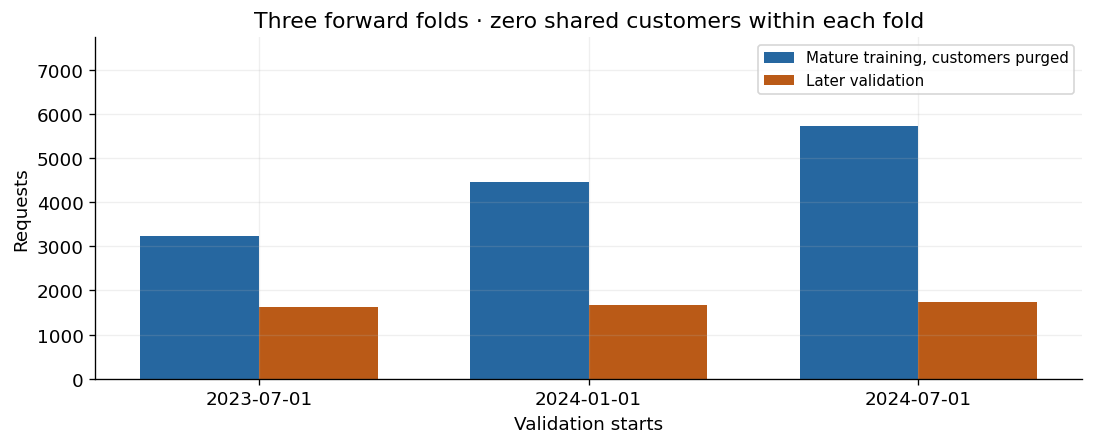

In [14]:
folds = make_time_group_split(clean, horizon_days=contract["target"]["horizon_days"])
fold_audit = pd.DataFrame([fold["audit"] for fold in folds])
for fold in folds:
    tr, va = clean.loc[fold["train"]], clean.loc[fold["valid"]]
    assert not set(tr.customer_id) & set(va.customer_id)
    assert (pd.to_datetime(tr.application_date) + pd.Timedelta(days=90) <
            pd.Timestamp(fold["audit"]["validation_start"])).all()
fold_audit["validation_positive_rate"] = fold_audit.validation_positives / fold_audit.validation_rows
display(fold_audit)

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})
fig, ax = plt.subplots(figsize=(9, 3.6), constrained_layout=True)
x = np.arange(len(fold_audit))
ax.bar(x - .18, fold_audit.train_rows, .36, label="Mature training, customers purged", color="#2667A0")
ax.bar(x + .18, fold_audit.validation_rows, .36, label="Later validation", color="#BA5A17")
ax.set(xticks=x, xticklabels=fold_audit.validation_start, ylabel="Requests", xlabel="Validation starts",
       title="Three forward folds · zero shared customers within each fold")
ax.set_ylim(0, fold_audit.train_rows.max() * 1.35)
ax.legend(fontsize=9)
fig.savefig(ARTIFACTS / "day2_fold_sizes.png", dpi=160)
plt.show()

In [15]:
pool = reserve_tuning_pool(clean, folds)
outer_ids = np.concatenate([fold["valid"] for fold in folds])
assert not set(pool.customer_id) & set(clean.loc[outer_ids, "customer_id"])
assert (pd.to_datetime(pool.application_date) + pd.Timedelta(days=90) < pd.Timestamp("2023-07-01")).all()
display(pd.DataFrame([{"search_rows": len(pool), "search_positives": int(pool[target].sum()),
    "search_positive_rate": pool[target].mean(), "latest_application": pool.application_date.max(),
    "outer_validation_rows": len(outer_ids)}]))

,search_rows,search_positives,search_positive_rate,latest_application,outer_validation_rows
0,1935,176,0.090956,2023-04-01,5039


,status,completed_trials,attempted_trials,elapsed_seconds,stopping_reason,best_tuning_ap
0,COMPLETE,8,8,1.29009,TRIAL_LIMIT,0.333269


,fold,validation_start,validation_end_exclusive,train_rows,validation_rows,train_positives,validation_positives,immature_past_rows_removed,customer_overlap_rows_removed,shared_customers,latest_training_label_available
0,1,2022-10-01,2023-01-01,703,381,52,42,351,99,0,2022-09-30
1,2,2023-01-01,2023-03-01,1070,271,83,27,373,91,0,2022-12-31
2,3,2023-03-01,2023-04-02,1355,130,118,15,389,61,0,2023-02-28


,trial,state,mean_ap,seconds,learning_rate,num_leaves,min_child_samples,fold_1_ap,fold_2_ap,fold_3_ap
0,0,COMPLETE,0.316524,0.144737,0.085161,15,10,0.319910,0.320935,0.308727
1,1,COMPLETE,0.333269,0.136904,0.085305,31,40,0.391154,0.349373,0.259279
2,2,COMPLETE,0.308752,0.179292,0.034906,31,40,0.404534,0.271448,0.250276
3,3,COMPLETE,0.320550,0.185275,0.040259,31,20,0.384913,0.316815,0.259923
4,4,COMPLETE,0.327798,0.158959,0.062862,15,40,0.403532,0.310814,0.269049
5,5,COMPLETE,0.319093,0.160665,0.037608,7,10,0.365309,0.299275,0.292694
6,6,COMPLETE,0.318537,0.157793,0.039240,15,40,0.414490,0.284021,0.257101
7,7,COMPLETE,0.319024,0.148360,0.062020,31,20,0.376677,0.322038,0.258357


Frozen search parameters: {'learning_rate': 0.08530488562858765, 'num_leaves': 31, 'min_child_samples': 40}


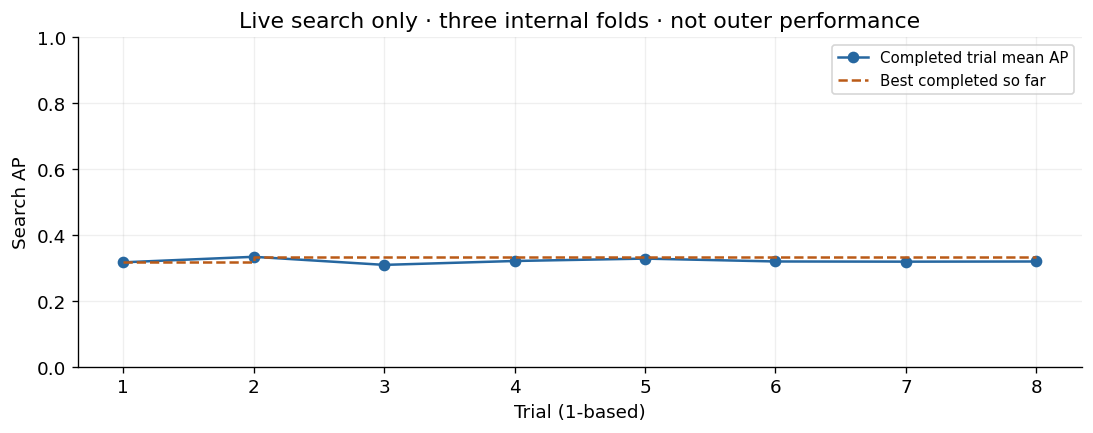

In [16]:
search, history = tune_on_reserved_pool(pool, contract, config)
has_tuned = search["best_params"] is not None
display(pd.DataFrame([{key: search[key] for key in ["status", "completed_trials", "attempted_trials",
    "elapsed_seconds", "stopping_reason", "best_tuning_ap"]}]))
display(pd.DataFrame(search["fold_audits"]))
display(history)
if not has_tuned:
    example = pd.read_csv(ROOT / "data/day2_optuna_example.csv")
    example_info = json.loads((ROOT / "data/day2_optuna_example.json").read_text(encoding="utf-8"))
    assert example_info["source"] == "EDUCATIONAL_EXAMPLE"
    print("EDUCATIONAL_EXAMPLE — discussion only; not your run or submission. TUNING_REQUIRED.")
    display(example)
else:
    print("Frozen search parameters:", search["best_params"])

fig, ax = plt.subplots(figsize=(9, 3.5), constrained_layout=True)
completed = history[history.state.eq("COMPLETE")]
if len(completed):
    ax.plot(completed.trial + 1, completed.mean_ap, marker="o", color="#2667A0", label="Completed trial mean AP")
    ax.step(completed.trial + 1, completed.mean_ap.cummax(), where="post", color="#BA5A17",
            linestyle="--", label="Best completed so far")
    ax.legend(fontsize=9)
else:
    ax.text(.5, .5, "No completed live trials — rerun needed", transform=ax.transAxes, ha="center")
ax.set(xlabel="Trial (1-based)", ylabel="Search AP", ylim=(0, 1), xticks=range(1, config.trials+1),
       title="Live search only · three internal folds · not outer performance")
fig.savefig(ARTIFACTS / "day2_search.png", dpi=160)
plt.show()

In [17]:
controls = negative_controls(clean, dirty, contract, config)
fixed_report, fixed_oof, fixed_origin = evaluate_outer(
    clean, contract, folds, BASE_PARAMS, config, "clean_time_group_fixed", fixed_trees=80)
reports, predictions, origins = [controls, fixed_report], [fixed_oof], fixed_origin
if has_tuned:
    tuned_report, tuned_oof, tuned_origin = evaluate_outer(
        clean, contract, folds, search["best_params"], config, "clean_time_group_tuned")
    reports.append(tuned_report); predictions.append(tuned_oof); origins += tuned_origin
validation_report = pd.concat(reports, ignore_index=True)
summary = summarize_folds(validation_report)
oof = pd.concat(predictions, ignore_index=True)
assert not oof.duplicated(["scheme", "application_id"]).any()
display(summary.round(4))
display(validation_report[["scheme", "fold", "roc_auc", "average_precision", "train_rows",
    "validation_rows", "selected_trees", "shared_customers", "prediction_source"]].round(4))
gaps = summary.set_index("scheme")
print("Observed AP gap, leaky minus clean random:",
      round(gaps.loc["leaky_random_control", "ap_mean"] - gaps.loc["clean_random_control", "ap_mean"], 4))
print("Observed AP gap, clean random minus honest fixed:",
      round(gaps.loc["clean_random_control", "ap_mean"] - gaps.loc["clean_time_group_fixed", "ap_mean"], 4))

,scheme,folds,validation_rows,roc_auc_mean,roc_auc_sd,ap_mean,ap_sd
0,leaky_random_control,3,10000,0.9999,0.0002,0.9988,0.0014
1,clean_random_control,3,10000,0.8010,0.0200,0.3110,0.0293
2,clean_time_group_fixed,3,5039,0.7976,0.0206,0.3153,0.0426
3,clean_time_group_tuned,3,5039,0.7855,0.0232,0.3133,0.0259


,scheme,fold,roc_auc,average_precision,train_rows,validation_rows,selected_trees,shared_customers,prediction_source
0,leaky_random_control,1,0.9996,0.9973,6666,3334,80,1713,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
1,clean_random_control,1,0.7807,0.2776,6666,3334,80,1713,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
2,leaky_random_control,2,0.9999,0.9992,6667,3333,80,1675,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
3,clean_random_control,2,0.8018,0.3232,6667,3333,80,1675,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
4,leaky_random_control,3,1.0000,1.0000,6667,3333,80,1656,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
5,clean_random_control,3,0.8206,0.3321,6667,3333,80,1656,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
6,clean_time_group_fixed,1,0.7948,0.3395,3223,1632,80,0,LIVE_OUT_OF_FOLD
7,clean_time_group_fixed,2,0.8194,0.3403,4460,1674,80,0,LIVE_OUT_OF_FOLD
8,clean_time_group_fixed,3,0.7786,0.2661,5731,1733,80,0,LIVE_OUT_OF_FOLD
9,clean_time_group_tuned,1,0.7826,0.3356,3223,1632,24,0,LIVE_OUT_OF_FOLD


Observed AP gap, leaky minus clean random: 0.6879
Observed AP gap, clean random minus honest fixed: -0.0044


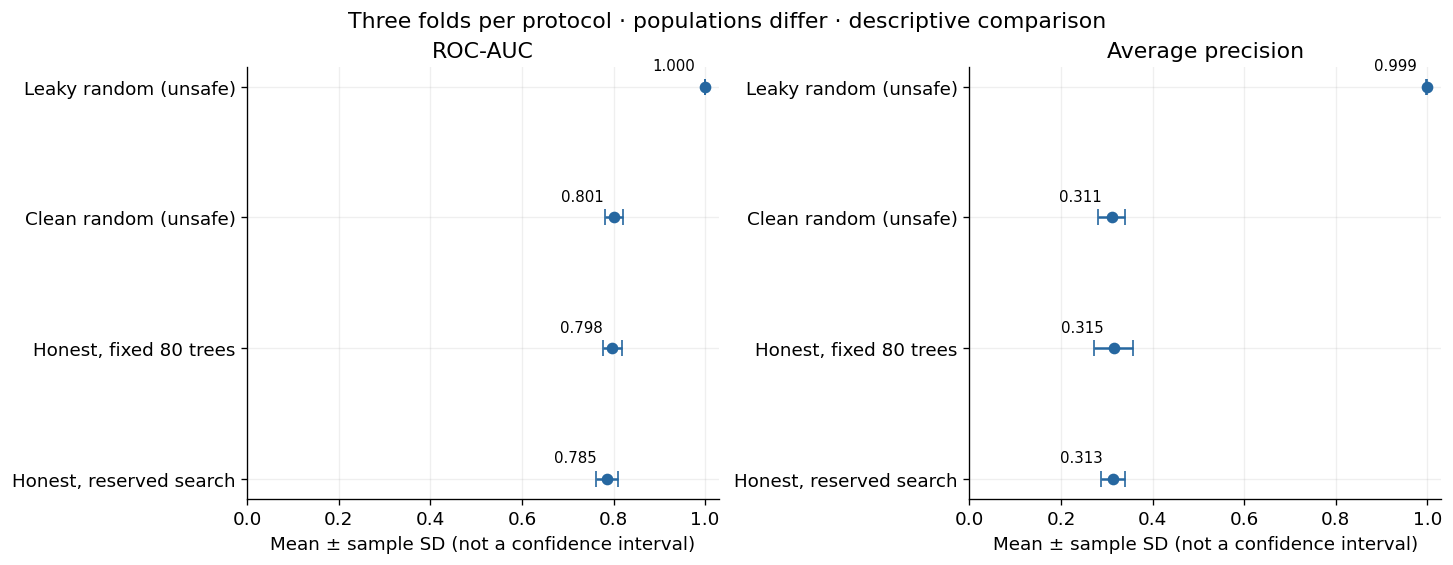

In [18]:
labels = {"leaky_random_control": "Leaky random (unsafe)", "clean_random_control": "Clean random (unsafe)",
          "clean_time_group_fixed": "Honest, fixed 80 trees", "clean_time_group_tuned": "Honest, reserved search"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
y = np.arange(len(summary))
for ax, mean_col, sd_col, title in zip(axes, ["roc_auc_mean", "ap_mean"], ["roc_auc_sd", "ap_sd"], ["ROC-AUC", "Average precision"]):
    ax.errorbar(summary[mean_col], y, xerr=summary[sd_col], fmt="o", capsize=5, color="#2667A0")
    ax.set(yticks=y, yticklabels=[labels[s] for s in summary.scheme], xlim=(0, 1.03),
           xlabel="Mean ± sample SD (not a confidence interval)", title=title)
    ax.invert_yaxis()
    for row, value in enumerate(summary[mean_col]):
        ax.annotate(f"{value:.3f}", (value, row), xytext=(-6, 10), textcoords="offset points", ha="right", fontsize=9)
fig.suptitle("Three folds per protocol · populations differ · descriptive comparison")
fig.savefig(ARTIFACTS / "day2_validation_comparison.png", dpi=160)
plt.show()

In [20]:
coverage = clean[["application_id", "application_date"]].copy()
coverage["role"], coverage["fold"] = "warmup_no_oof", 0
for fold in folds:
    coverage.loc[fold["valid"], "role"] = "eligible_oof"
    coverage.loc[fold["valid"], "fold"] = fold["audit"]["fold"]
eligible_ids = set(coverage.loc[coverage.role.eq("eligible_oof"), "application_id"])
for scheme, group in oof.groupby("scheme"):
    assert set(group.application_id) == eligible_ids
    assert group.probability.between(0, 1).all()
display(pd.DataFrame([{"all_rows": len(clean), "eligible_rows": len(eligible_ids),
    "warmup_without_oof": len(clean)-len(eligible_ids), "whole_data_coverage": len(eligible_ids)/len(clean),
    "eligible_coverage": 1.0, "live_honest_schemes": oof.scheme.nunique()}]))

,all_rows,eligible_rows,warmup_without_oof,whole_data_coverage,eligible_coverage,live_honest_schemes
0,10000,5039,4961,0.5039,1.0,2


In [21]:
responses = {
    "leak_example": "days_past_due_60 is a leaked field: it only exists after the loan is active and the customer misses payments, so it is not available at application time.",
    "split_reason": "We train on earlier periods and validate on later ones, like real use. Each customer stays on one side only (0 shared customers), and training uses only labels at least 90 days old so the outcome is truly known.",
    "observed_gap": "Leaky minus clean random AP was +0.688, and clean random minus honest fixed AP was -0.004. These come from 3 related time folds of one synthetic dataset, so they describe this run only and do not prove universal superiority.",
    "imputer_reason": "Imputation is learned inside each training fold so validation values never influence it. The inner stopping set only chooses the number of trees and is never used to report the final score.",
    "limitations": "Search budget: only 8 trials on 1,935 rows with 176 defaults, so the chosen parameters may be unstable (tuned AP 0.313 was not better than fixed 0.315). OOF covers only 50.39% of rows, and the 3 folds are related time periods, not independent samples."
}
checkpoint = reflection_check(responses)
print(checkpoint["status"])
print("Missing:", checkpoint["missing"])

READY_FOR_REVIEW
Missing: []


In [22]:
checkpoint = reflection_check(responses)
technical_status = "TECHNICAL_READY" if has_tuned else "TUNING_REQUIRED"
csv_outputs = {"validation_report.csv": validation_report, "validation_summary.csv": summary,
    "optuna_results.csv": history, "leakage_audit.csv": audit, "fold_audit.csv": fold_audit,
    "day2_oof_predictions.csv": oof, "day2_oof_coverage.csv": coverage}
for filename, table in csv_outputs.items():
    table.to_csv(ARTIFACTS / filename, index=False)
run = {"technical_status": technical_status, "learner_status": checkpoint["status"],
    "data_revision": COURSE_REVISION, "lab_revision": LAB_REVISION, "support_sha256": SUPPORT_HASHES,
    "data_manifest_sha256": MANIFEST_SHA256,
    "dirty_data_sha256": hashlib.sha256((ROOT / "data/tamweel_dirty.csv").read_bytes()).hexdigest(),
    "config": asdict(config), "mode": "FAST" if FAST_MODE else "FULL", "python": platform.python_version(),
    "duplicates": duplicates, "removed_features": leaked_features,
    "oof_rows_per_scheme": {name: len(group) for name, group in oof.groupby("scheme")},
    "oof_whole_data_coverage": len(eligible_ids)/len(clean), "warmup_rows": len(clean)-len(eligible_ids),
    "search_source": "LIVE", "example_used_for_results": False,
    "challenge_used_for_modeling": False, "grading": "No automatic grade"}
json_outputs = {"best_params.json": search, "day2_provenance.json": origins,
                "day2_reflection.json": {"responses": responses, "checkpoint": checkpoint}, "day2_run.json": run}
for filename, payload in json_outputs.items():
    (ARTIFACTS / filename).write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
files = list(csv_outputs) + list(json_outputs) + ["day2_fold_sizes.png", "day2_search.png",
    "day2_validation_comparison.png", "environment.json"]
with zipfile.ZipFile(ARTIFACTS / "day2_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as archive:
    for filename in files:
        assert (ARTIFACTS / filename).is_file(), filename
        archive.write(ARTIFACTS / filename, arcname=filename)
print(technical_status, "|", checkpoint["status"])
print(f"Saved {len(files)} files in day2_artifacts.zip | احفظ الدفتر وملفاتك ثم أكمل تفسيرك")

TECHNICAL_READY | READY_FOR_REVIEW
Saved 15 files in day2_artifacts.zip | احفظ الدفتر وملفاتك ثم أكمل تفسيرك


### Day 2 summary – Shatha Alsubaie
**Goal:** replace the random split with honest validation.

| Protocol | Mean AP | Shared customers |
|---|---|---|
| Leaky random (unsafe) | 0.999 | ~1,700 |
| Clean random (unsafe) | 0.311 | ~1,700 |
| **Honest, fixed settings** | **0.315** | **0** |
| Honest, Optuna settings | 0.313 | 0 |

- **Leakage removed:** `days_past_due_60` and `collection_calls` (only available after the application).
- **Leakage effect:** it inflated AP by +0.688, which makes the model look almost perfect when it is not.
- **Honest split:** 3 time folds, 0 shared customers, and only labels at least 90 days old.
- **Optuna:** 8 trials on 1,935 rows did not beat the fixed settings, so the search is not proven useful.
- **Limitation:** AP drops to 0.27 in the latest fold, and OOF covers only 50.39% of rows.

---
# Day 3 – Cost-Sensitive Decision
*Source notebook: `03_cost_sensitive_decision.ipynb`*

# Day 3 · Cost-sensitive decision

In [ ]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
DAY2_REVISION = "1e1da4acbee8941bef07245b259fb6c27ced4ad7"
DAY2_SHA256 = "d2fd0353330c3629bdaed6c570528792955fce232540a85d33532a9432522f43"
fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{DAY2_REVISION}/scripts/day2_validation.py",
               ROOT / "scripts/day2_validation.py", DAY2_SHA256)
LAB_REVISION = "c2dc52e129878d0d487db1874891c658de7c4d0d"
SUPPORT_HASHES = {'scripts/day3_decision.py': '40f176633c91fc530db222978bc44495a401b888b1ce448728948f7ae0ca9e12', 'data/day3_oof_example.csv': '659952bef85ac3b7ceb7ab84eb2102de6c9b433a1ba122cd57df96581baf0eb3', 'data/day3_oof_example.json': '920cf9830043afcc83f8c276c8945677296eb3c49a6e69326d47f6080a9e7fad'}
for relative, digest in SUPPORT_HASHES.items():
    fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/{relative}",
                   ROOT / relative, digest)
print("Day 3 setup verified | إعداد اليوم الثالث جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.16 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 3 setup verified | إعداد اليوم الثالث جاهز


In [ ]:
import json, platform, zipfile
from dataclasses import asdict, replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from IPython.display import display
from data_checks import validate_frame
from day2_validation import deduplicate_applications, make_time_group_split
from day3_decision import (STRATEGIES, TARGET, DecisionConfig, CostPolicy, generate_oof,
    validate_oof, threshold_sweep, select_threshold, flag_at, period_audit, region_audit,
    reflection_check, load_example, TrainingBudgetExpired)

contract = json.loads((ROOT / "data/data_contract.json").read_text(encoding="utf-8"))
train, duplicates = deduplicate_applications(pd.read_csv(ROOT / "data/tamweel_train.csv"))
validate_frame(train, contract, "train")
FAST_MODE, FULL_MODE = True, False
assert FAST_MODE != FULL_MODE
config = DecisionConfig(trees=80 if FAST_MODE else 160)
policy = CostPolicy(**contract["decision_policy"])
MODEL_FOR_DECISION = "weighted"  # Declared before comparison; not a claim of superiority.
USE_EXAMPLE = False  # True is discussion only, never your submission.
ASSESSMENT_MODE = os.environ.get("ASSESSMENT_MODE", "0") == "1"
assert MODEL_FOR_DECISION in STRATEGIES
ARTIFACTS, REPORTS = ROOT / "artifacts", ROOT / "reports"
ARTIFACTS.mkdir(exist_ok=True); REPORTS.mkdir(exist_ok=True)
folds = make_time_group_split(train, horizon_days=contract["target"]["horizon_days"])
display(pd.DataFrame([{"training_rows": len(train), "positive_rate": train[TARGET].mean(),
    "FN_loss_units": policy.false_negative_cost, "FP_loss_units": policy.false_positive_cost,
    "period_capacity_fraction": policy.max_flag_fraction, "trees_per_model": config.trees}]))
display(pd.DataFrame([fold["audit"] for fold in folds]))

,training_rows,positive_rate,FN_loss_units,FP_loss_units,period_capacity_fraction,trees_per_model
0,10000,0.0789,10,1,0.12,80


,fold,validation_start,validation_end_exclusive,train_rows,validation_rows,train_positives,validation_positives,immature_past_rows_removed,customer_overlap_rows_removed,shared_customers,latest_training_label_available
0,1,2023-07-01,2024-01-01,3223,1632,274,110,826,912,0,2023-06-30
1,2,2024-01-01,2024-07-01,4460,1674,353,135,785,1348,0,2023-12-31
2,3,2024-07-01,2025-01-01,5731,1733,465,139,861,1675,0,2024-06-30


In [ ]:
fallback_reason = None
if not USE_EXAMPLE:
    try:
        oof, model_report, provenance = generate_oof(train, contract, config)
    except TrainingBudgetExpired as exc:
        if ASSESSMENT_MODE:
            raise
        USE_EXAMPLE, fallback_reason = True, str(exc)
if USE_EXAMPLE:
    oof, example_info = load_example(ROOT / "data/day3_oof_example.csv",
        ROOT / "data/day3_oof_example.json", train, folds, assessment_mode=ASSESSMENT_MODE)
    model_report = pd.DataFrame(example_info["model_report"])
    provenance = {"source": "EDUCATIONAL_EXAMPLE", "example_metadata": example_info,
                  "fallback_reason": fallback_reason or "Learner selected discussion example"}
SOURCE = oof.source.iloc[0]
effective_config = example_info["config"] if USE_EXAMPLE else asdict(config)
coverage = validate_oof(oof, train, folds)
print("LIVE — your CPU run" if SOURCE == "LIVE" else
      "EDUCATIONAL_EXAMPLE — discussion only; EXAMPLE_ONLY_NOT_SUBMITTABLE")
display(pd.DataFrame([coverage]))
display(model_report[["strategy", "fold", "original_training_rows", "fitted_rows",
    "scale_pos_weight", "training_positive_rate", "fitted_positive_rate", "average_precision",
    "train_seconds", "source"]].round(4))
selected = oof[oof.strategy.eq(MODEL_FOR_DECISION)].copy()
assert selected.application_id.is_unique
print(f"Decision strategy declared before comparison: {MODEL_FOR_DECISION}")

LIVE — your CPU run


,eligible_rows,all_rows,whole_data_coverage,eligible_coverage,warmup_without_oof,source
0,5039,10000,0.5039,1.0,4961,LIVE


,strategy,fold,original_training_rows,fitted_rows,scale_pos_weight,training_positive_rate,fitted_positive_rate,average_precision,train_seconds,source
0,unweighted,1,3223,3223,1.0000,0.0850,0.0850,0.3395,0.1350,LIVE
1,weighted,1,3223,3223,10.7628,0.0850,0.0850,0.3378,0.0902,LIVE
2,oversampled,1,3223,5898,1.0000,0.0850,0.5000,0.3502,0.1605,LIVE
3,unweighted,2,4460,4460,1.0000,0.0791,0.0791,0.3403,0.1053,LIVE
4,weighted,2,4460,4460,11.6346,0.0791,0.0791,0.3295,0.1150,LIVE
5,oversampled,2,4460,8214,1.0000,0.0791,0.5000,0.3390,1.1735,LIVE
6,unweighted,3,5731,5731,1.0000,0.0811,0.0811,0.2661,0.6218,LIVE
7,weighted,3,5731,5731,11.3247,0.0811,0.0811,0.2707,0.5846,LIVE
8,oversampled,3,5731,10532,1.0000,0.0811,0.5000,0.2776,0.9238,LIVE


Decision strategy declared before comparison: weighted


,strategy,rows,positive_rate,pooled_roc_auc,pooled_ap,accuracy_at_0_5,recall_at_0_5,precision_at_0_5,flags_at_0_5,loss_at_0_5,capacity_ok_at_0_5,source
0,unweighted,5039,0.0762,0.7979,0.3091,0.9256,0.1250,0.5517,87,3399,True,LIVE
1,weighted,5039,0.0762,0.7969,0.3100,0.8125,0.5781,0.2209,1005,2403,False,LIVE
2,oversampled,5039,0.0762,0.7979,0.3159,0.8073,0.5990,0.2197,1047,2357,False,LIVE


,rule,rows,accuracy,recall,precision,loss_units
0,No flags for anyone,5039,0.923794,0.0,None,3840


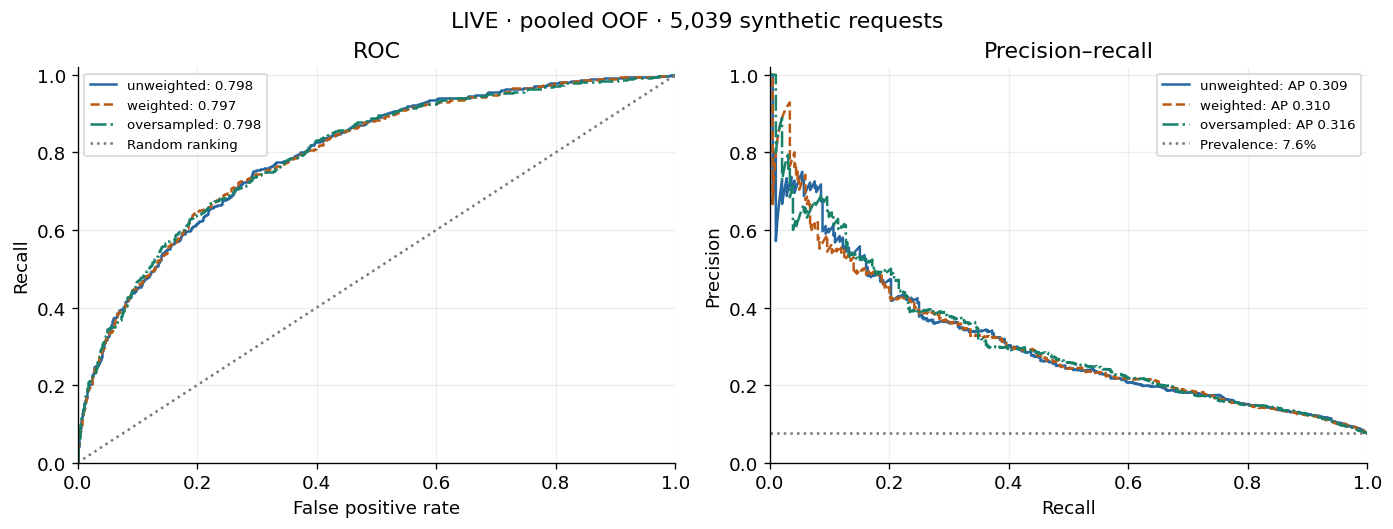

In [ ]:
comparison_rows = []
for strategy, group in oof.groupby("strategy", sort=False):
    sweep = threshold_sweep(group, policy)
    default = sweep.loc[sweep.threshold.eq(.5)].iloc[0]
    comparison_rows.append({"strategy": strategy, "rows": len(group), "positive_rate": group[TARGET].mean(),
        "pooled_roc_auc": roc_auc_score(group[TARGET], group.probability),
        "pooled_ap": average_precision_score(group[TARGET], group.probability),
        "accuracy_at_0_5": default.accuracy, "recall_at_0_5": default.recall,
        "precision_at_0_5": default.precision, "flags_at_0_5": default.flagged,
        "loss_at_0_5": default.loss_units, "capacity_ok_at_0_5": default.capacity_feasible, "source": SOURCE})
comparison = pd.DataFrame(comparison_rows)
display(comparison.round(4))
no_flag_reference = {"rule": "No flags for anyone", "rows": len(selected),
    "accuracy": 1-selected[TARGET].mean(), "recall": 0., "precision": None,
    "loss_units": int(selected[TARGET].sum()) * policy.false_negative_cost}
display(pd.DataFrame([no_flag_reference]))

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120, "axes.grid": True, "grid.alpha": .2})
colors = {"unweighted": "#2667A0", "weighted": "#BA5A17", "oversampled": "#18816A"}
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), constrained_layout=True)
for strategy, style in zip(STRATEGIES, ["-", "--", "-."]):
    group = oof[oof.strategy.eq(strategy)]
    fpr, tpr, _ = roc_curve(group[TARGET], group.probability)
    precision, recall, _ = precision_recall_curve(group[TARGET], group.probability)
    row = comparison.set_index("strategy").loc[strategy]
    axes[0].plot(fpr, tpr, color=colors[strategy], linestyle=style, label=f"{strategy}: {row.pooled_roc_auc:.3f}")
    axes[1].plot(recall, precision, color=colors[strategy], linestyle=style, label=f"{strategy}: AP {row.pooled_ap:.3f}")
axes[0].plot([0,1], [0,1], color="#777777", linestyle=":", label="Random ranking")
axes[1].axhline(selected[TARGET].mean(), color="#777777", linestyle=":", label=f"Prevalence: {selected[TARGET].mean():.1%}")
axes[0].set(title="ROC", xlabel="False positive rate", ylabel="Recall")
axes[1].set(title="Precision–recall", xlabel="Recall", ylabel="Precision")
for ax in axes:
    ax.set_xlim(0,1); ax.set_ylim(0,1.02); ax.legend(fontsize=8)
fig.suptitle(f"{SOURCE} · pooled OOF · {len(selected):,} synthetic requests")
fig.savefig(ARTIFACTS / "day3_roc_pr.png", dpi=160)
plt.show()

,rule,threshold,tp,fp,fn,tn,recall,precision,flagged,flag_fraction,loss_units,loss_units_per_10000,capacity_feasible
0,Default 0.5,0.5000,222,783,162,3872,0.5781,0.2209,1005,0.1994,2403,4768.8033,False
1,"Minimum loss, no capacity limit",0.4486,246,895,138,3760,0.6406,0.2156,1141,0.2264,2275,4514.7847,False
2,"Minimum loss, every-period capacity",0.6583,157,369,227,4286,0.4089,0.2985,526,0.1044,2639,5237.1502,True


Constrained minus default loss: +236 educational units. Default feasible: False
Exact rule to preserve in JSON: 0.6583471436014694 with >=


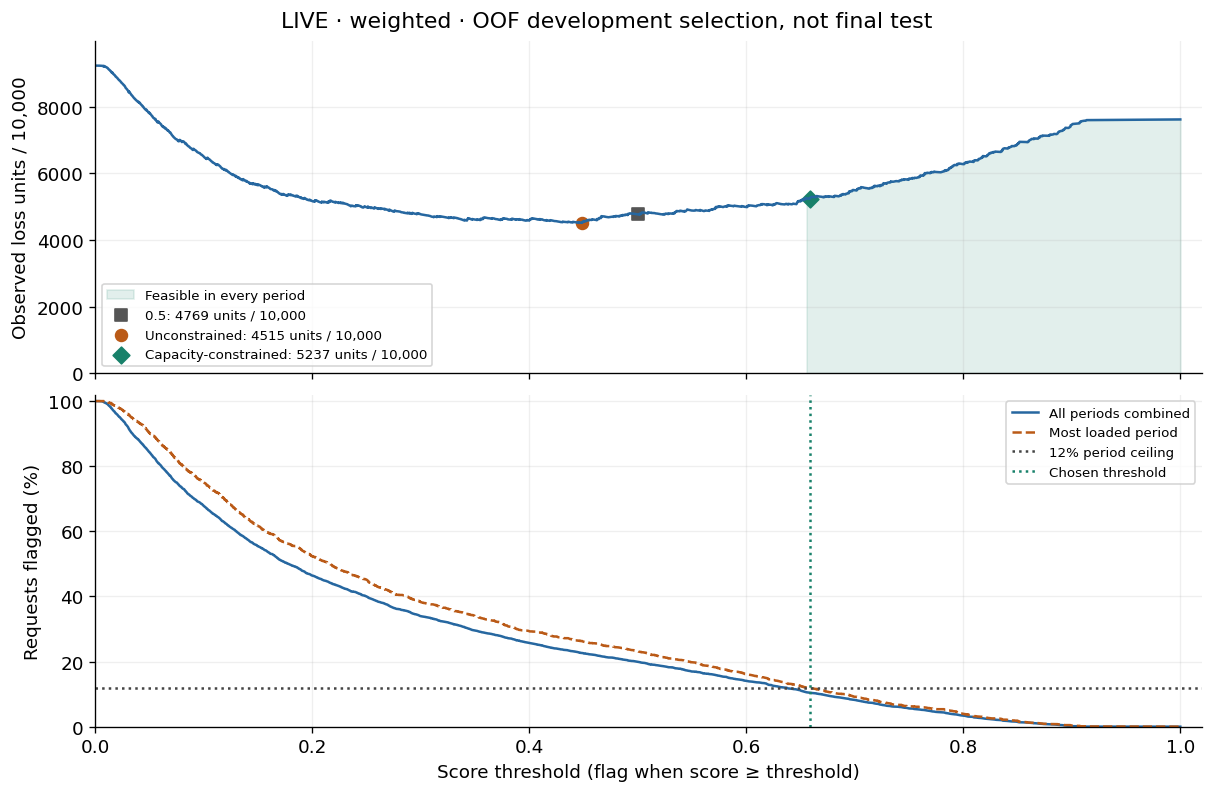

In [ ]:
cost_curve = threshold_sweep(selected, policy)
unconstrained = select_threshold(cost_curve, constrained=False)
chosen = select_threshold(cost_curve, constrained=True)
default = cost_curve.loc[cost_curve.threshold.eq(.5)].iloc[0].to_dict()
operating_points = pd.DataFrame([{**point, "rule": name} for name, point in
    [("Default 0.5", default), ("Minimum loss, no capacity limit", unconstrained),
     ("Minimum loss, every-period capacity", chosen)]])
display(operating_points[["rule", "threshold", "tp", "fp", "fn", "tn", "recall", "precision",
    "flagged", "flag_fraction", "loss_units", "loss_units_per_10000", "capacity_feasible"]].round(4))
assert unconstrained["loss_units"] <= default["loss_units"]
if default["capacity_feasible"]:
    assert chosen["loss_units"] <= default["loss_units"]
periods = period_audit(selected, chosen["threshold"], policy)
assert periods.within_capacity.all()
delta = chosen["loss_units"] - default["loss_units"]
print(f"Constrained minus default loss: {delta:+.0f} educational units. Default feasible: {default['capacity_feasible']}")
print("Exact rule to preserve in JSON:", repr(chosen["threshold"]), "with >=")

fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True, constrained_layout=True)
axes[0].plot(cost_curve.threshold, cost_curve.loss_units_per_10000, color="#2667A0")
axes[0].fill_between(cost_curve.threshold, 0, cost_curve.loss_units_per_10000,
    where=cost_curve.capacity_feasible, color="#18816A", alpha=.12, label="Feasible in every period")
for label, point, marker, color in [("0.5", default, "s", "#555555"),
    ("Unconstrained", unconstrained, "o", "#BA5A17"), ("Capacity-constrained", chosen, "D", "#18816A")]:
    axes[0].scatter([point["threshold"]], [point["loss_units_per_10000"]], marker=marker, color=color, s=50,
        label=f"{label}: {point['loss_units_per_10000']:.0f} units / 10,000")
axes[0].set(ylabel="Observed loss units / 10,000", ylim=(0, cost_curve.loss_units_per_10000.max()*1.08))
axes[0].legend(fontsize=8)
axes[1].plot(cost_curve.threshold, cost_curve.flag_fraction*100, label="All periods combined", color="#2667A0")
axes[1].plot(cost_curve.threshold, cost_curve.max_period_flag_fraction*100, linestyle="--",
    label="Most loaded period", color="#BA5A17")
axes[1].axhline(policy.max_flag_fraction*100, color="#444444", linestyle=":", label="12% period ceiling")
axes[1].axvline(chosen["threshold"], color="#18816A", linestyle=":", label="Chosen threshold")
axes[1].set(xlabel="Score threshold (flag when score ≥ threshold)", ylabel="Requests flagged (%)", ylim=(0,102), xlim=(0,1.02))
axes[1].legend(fontsize=8)
fig.suptitle(f"{SOURCE} · {MODEL_FOR_DECISION} · OOF development selection, not final test")
fig.savefig(ARTIFACTS / "cost_curve.png", dpi=160)
plt.show()

In [ ]:
display(periods)
sensitivity_rows = []
for fn_cost in [8., 10., 12.]:
    scenario_policy = replace(policy, false_negative_cost=fn_cost)
    scenario = select_threshold(threshold_sweep(selected, scenario_policy))
    sensitivity_rows.append({"FN_loss_units": fn_cost, "FP_loss_units": policy.false_positive_cost,
        "capacity_fraction": policy.max_flag_fraction, "threshold": scenario["threshold"],
        "flagged": scenario["flagged"], "recall": scenario["recall"],
        "loss_units": scenario["loss_units"], "capacity_feasible": scenario["capacity_feasible"], "source": SOURCE})
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.round(4))
print("Theoretical threshold 1/11 ≈ 0.0909 requires calibrated probabilities, this loss matrix and no capacity limit.")
print("Do not impose that formula on today's weighted raw scores.")

,fold,rows,capacity,flagged,flag_fraction,within_capacity,source
0,1,1632,195,137,0.083946,True,LIVE
1,2,1674,200,183,0.109319,True,LIVE
2,3,1733,207,206,0.118869,True,LIVE


,FN_loss_units,FP_loss_units,capacity_fraction,threshold,flagged,recall,loss_units,capacity_feasible,source
0,8.0,1,0.12,0.6583,526,0.4089,2185.0,True,LIVE
1,10.0,1,0.12,0.6583,526,0.4089,2639.0,True,LIVE
2,12.0,1,0.12,0.6583,526,0.4089,3093.0,True,LIVE


Theoretical threshold 1/11 ≈ 0.0909 requires calibrated probabilities, this loss matrix and no capacity limit.
Do not impose that formula on today's weighted raw scores.


,region,rows,negatives,positives,flagged,false_positives,true_positives,false_positive_rate,recall,low_negative_support,source
0,central,1184,1088,96,131,88,43,0.0809,0.4479,False,LIVE
1,western,1262,1158,104,132,96,36,0.0829,0.3462,False,LIVE
2,eastern,1295,1192,103,131,92,39,0.0772,0.3786,False,LIVE
3,other,1298,1217,81,132,93,39,0.0764,0.4815,False,LIVE


FPR gap (percentage points): 0.6484134519182061


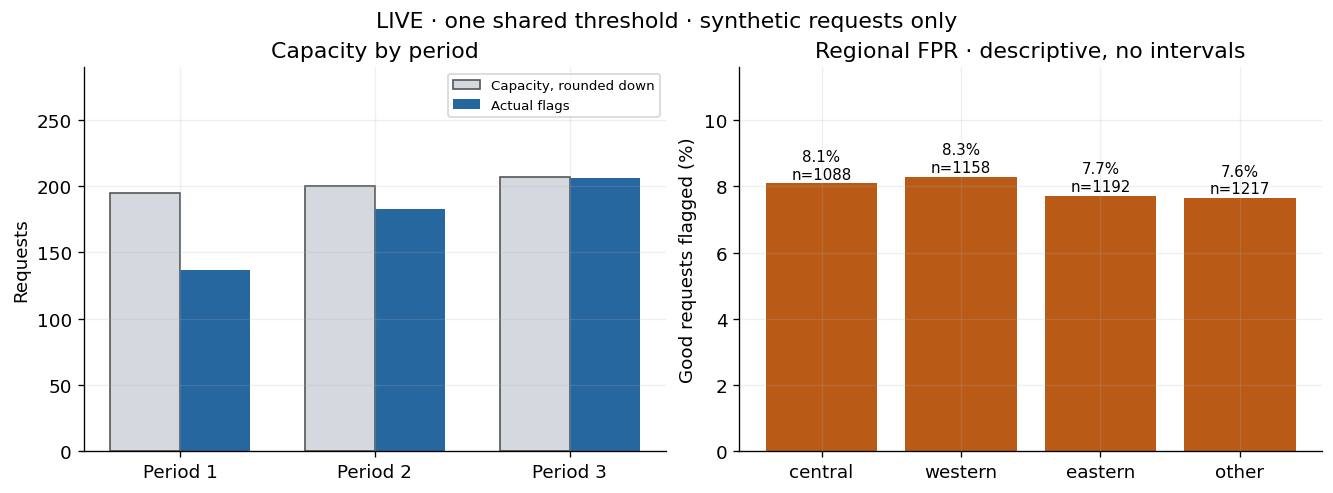

In [ ]:
regions, gap_info = region_audit(selected, chosen["threshold"])
display(regions.round(4))
print("FPR gap (percentage points):", gap_info["fpr_gap_percentage_points"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
x = np.arange(len(periods))
axes[0].bar(x-.18, periods.capacity, .36, color="#D3D9DE", edgecolor="#555555", label="Capacity, rounded down")
axes[0].bar(x+.18, periods.flagged, .36, color="#2667A0", label="Actual flags")
axes[0].set(xticks=x, xticklabels=[f"Period {n}" for n in periods.fold], ylabel="Requests", title="Capacity by period")
axes[0].set_ylim(0, periods.capacity.max()*1.4)
axes[0].legend(fontsize=8)
axes[1].bar(regions.region, regions.false_positive_rate*100, color="#BA5A17")
axes[1].set(ylabel="Good requests flagged (%)", title="Regional FPR · descriptive, no intervals")
for i, row in enumerate(regions.itertuples()):
    if pd.notna(row.false_positive_rate):
        axes[1].text(i, row.false_positive_rate*100+.15, f"{row.false_positive_rate:.1%}\nn={row.negatives}", ha="center", fontsize=9)
axes[1].set_ylim(0, max(10, regions.false_positive_rate.max()*140))
fig.suptitle(f"{SOURCE} · one shared threshold · synthetic requests only")
fig.savefig(ARTIFACTS / "day3_capacity_regions.png", dpi=160)
plt.show()

In [ ]:
responses = {
    "threshold_reason": "The threshold 0.6583 is the lowest-loss rule that keeps flags under the 12% capacity in every period (8.4%, 10.9% and 11.9%). The default 0.5 flags 19.9% of requests, so it is not feasible. The threshold also stays the same when the FN cost is 8, 10 or 12, so the decision is driven by capacity, not by the exact cost value.",
    "cost_capacity_tradeoff": "Respecting capacity costs 2,639 loss units, which is +236 vs the default 0.5 (2,403) and +364 vs the unconstrained minimum at 0.449 (2,275). Recall drops from 57.8% to 40.9%, but precision rises from 22.1% to 29.9% and false positives fall from 783 to 369, with 526 flags instead of 1,005.",
    "regional_gap": "With one shared threshold, the false-positive rate ranges from 7.6% (other) to 8.3% (western), a gap of 0.65 percentage points, and every region has more than 1,000 non-default cases. Recall varies more, from 34.6% (western) to 48.1% (other), so recall by region needs review and monitoring. This is a descriptive audit on synthetic data, not a fairness certification.",
    "limitations": "The threshold was chosen on the same OOF development rows, so the reported loss is optimistic and is not final-test performance. OOF covers only 5,039 of 10,000 rows (50.39%). The weighted scores are not calibrated probabilities. Period 3 is at 11.9%, very close to the 12% ceiling, so future volume changes could break capacity. The data is synthetic.",
    "why_accuracy_misleads": "Only 7.6% of requests default. Flagging nobody gives 92.4% accuracy with 0% recall, and the unweighted model at 0.5 has 92.6% accuracy but catches only 12.5% of defaults. Accuracy rewards ignoring the rare class, so we use AP, recall, precision, flags and loss instead.",
    "why_oof": "Training predictions come from models that already saw those labels, so they are over-confident and a threshold chosen on them would be too optimistic. OOF predictions come from models that did not see those rows, so they behave more like new applications and give a more honest basis for choosing the threshold."
}
checkpoint = reflection_check(responses, SOURCE)
print(checkpoint["status"], "| missing:", checkpoint["missing"])

READY_FOR_REVIEW | missing: []


In [ ]:
def json_safe(value):
    if isinstance(value, dict): return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)): return [json_safe(v) for v in value]
    if isinstance(value, np.generic): value = value.item()
    if isinstance(value, float) and not np.isfinite(value): return None
    return value

checkpoint = reflection_check(responses, SOURCE)
status = "TECHNICAL_READY" if SOURCE == "LIVE" else "EXAMPLE_ONLY_NOT_SUBMITTABLE"
pooled_ap = float(average_precision_score(selected[TARGET], selected.probability))
threshold_metrics = {"source": SOURCE, "technical_status": status, "strategy": MODEL_FOR_DECISION,
    "policy": asdict(policy), "unit": "educational_loss_unit", "comparison_operator": ">=",
    "capacity_scope": "every validation period; floor(fraction * period_rows)",
    "chosen": chosen, "unconstrained": unconstrained, "default_0_5": default,
    "loss_change_vs_default": delta, "pooled_oof_ap": pooled_ap, "regional_audit": gap_info,
    "coverage": coverage, "selection_status": "OOF development selection; not an independent final test"}
membership = train[["application_id", "application_date"]].copy()
membership["role"], membership["fold"] = "warmup_no_oof", 0
for fold in folds:
    membership.loc[fold["valid"], "role"] = "eligible_oof"
    membership.loc[fold["valid"], "fold"] = fold["audit"]["fold"]
membership["source"] = SOURCE
decisions = selected.copy()
decisions["review_flag"] = flag_at(selected.probability, chosen["threshold"]).astype(int)
csv_outputs = {"day3_model_report.csv": model_report, "day3_model_comparison.csv": comparison,
    "day3_oof_predictions.csv": oof, "day3_oof_coverage.csv": membership, "threshold_sweep.csv": cost_curve,
    "day3_period_capacity.csv": periods, "day3_region_audit.csv": regions,
    "day3_cost_sensitivity.csv": sensitivity, "day3_review_flags.csv": decisions}
for filename, table in csv_outputs.items(): table.to_csv(ARTIFACTS / filename, index=False)
run = {"technical_status": status, "learner_status": checkpoint["status"], "source": SOURCE,
    "requested_config": asdict(config), "effective_config": effective_config, "assessment_mode": ASSESSMENT_MODE,
    "data_revision": COURSE_REVISION, "lab_revision": LAB_REVISION, "support_sha256": SUPPORT_HASHES,
    "day2_revision": DAY2_REVISION, "day2_sha256": DAY2_SHA256, "manifest_sha256": MANIFEST_SHA256,
    "training_data_sha256": hashlib.sha256((ROOT / "data/tamweel_train.csv").read_bytes()).hexdigest(),
    "python": platform.python_version(), "elapsed_seconds": round(time.perf_counter()-RUN_STARTED,2),
    "coverage": coverage, "challenge_used_for_modeling": False, "no_automatic_grade": True}
if IN_COLAB:
    import resource
    run["peak_process_memory_mib"] = round(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss/1024,1)
json_outputs = {"threshold_metrics.json": threshold_metrics, "day3_provenance.json": provenance,
    "day3_reflection.json": {"source": SOURCE, "responses": responses, "checkpoint": checkpoint}, "day3_run.json": run}
for filename, payload in json_outputs.items():
    (ARTIFACTS / filename).write_text(json.dumps(json_safe(payload), ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")

answer = lambda key: responses[key].strip() or "[اكتب تفسيرك من نتائجك هنا]"
rate_text = lambda value: f"{value:.2%}" if pd.notna(value) else "غير معرّفة لغياب المقام"
card_status = ("مثال تعليمي غير صالح للتسليم كتجربة شخصية" if SOURCE != "LIVE" else
               "مسودة — أكمل تفسيرك" if checkpoint["missing"] else "جاهزة للمراجعة؛ لا تعني اعتمادًا أو درجة")
card = f"""# بطاقة قرارك — Tamweel Lite

**الحالة:** {card_status}
**مصدر الأرقام:** {SOURCE} · **الاستراتيجية:** {MODEL_FOR_DECISION} · **الصفوف:** {len(selected):,} OOF

**المهمة:** الفئة الموجبة `default_within_90d=1` تعني حدث تعثر اصطناعي خلال90 يومًا بعد الطلب. كل طية تحقق طلبات لاحقة، وتستبعد عملاءها من التدريب وتشترط نضج نتيجة التدريب قبل بدايتها. المعرّفات والتاريخ خارج المدخلات.

| الدليل | القيمة |
|---|---:|
| العتبة المقيدة، بالقيمة الكاملة | {repr(chosen['threshold'])} |
| عتبة أقل خسارة دون قيد | {repr(unconstrained['threshold'])} |
| Recall | {rate_text(chosen['recall'])} |
| Precision | {rate_text(chosen['precision'])} |
| AP مجمع منOOF | {pooled_ap:.4f} |
| الإشارات | {chosen['flagged']:,} من {len(selected):,} |
| FN / FP | {chosen['fn']} / {chosen['fp']} |
| الخسارة التعليمية | {chosen['loss_units']:.0f} وحدة |
| خسارة0.5 | {default['loss_units']:.0f} وحدة؛ ضمن السعة: {default['capacity_feasible']} |
| التغير عن0.5 | {delta:+.0f} وحدة؛ الموجب زيادة |
| خسارة لكل10,000 طلب، تطبيع حسابي | {chosen['loss_units_per_10000']:.2f} وحدة |
| فجوة معدل الإنذار الخاطئ بين المناطق | {gap_info['fpr_gap_percentage_points']:.3f} نقطة مئوية |

**القاعدة:** درجة ≥ {repr(chosen['threshold'])} تعني إشارة مراجعة داخل التمرين؛ غير ذلك بلا إشارة. لا تتخذ موافقة أو رفض تمويل حقيقي. احفظ الدقة الكاملة؛ تقريب العتبة قد يغيّر حجم الطابور.

**السياسة:** FN={policy.false_negative_cost:g} وFP={policy.false_positive_cost:g} وحدات تعليمية، وسعة {policy.max_flag_fraction:.0%} لكل فترة بعد التقريب لأسفل. ليست ريالات فعلية أو رسوم أدوات أو خصمًا من الدرجة.

**دليل السعة:** {', '.join(f"الفترة {int(row.fold)}: {int(row.flagged)}/{int(row.capacity)}" for row in periods.itertuples())}.

## لماذا اخترت هذه العتبة؟
{answer('threshold_reason')}

## الخسارة والسعة
{answer('cost_capacity_tradeoff')}

## فرق المناطق وما يحتاج إلى مراجعة
{answer('regional_gap')}

## حدود النتيجة
{answer('limitations')}

OOF تغطي {coverage['whole_data_coverage']:.2%} من التدريب و100% من الصفوف المؤهلة؛ {coverage['warmup_without_oof']:,} صفًا تمهيديًا بلا تنبؤ. اختيار العتبة وتقدير خسارتها هنا يستخدمان أهدافOOF نفسها؛ هذه نتيجة تطوير لا اختبار نهائي. لم نستخدم التحدي. المقارنة الجغرافية وصفية وليست شهادة عدالة، والأوزان لا تضمن معايرة الدرجات.

## سؤالك الأول: لماذا قد تخدعكAccuracy؟
{answer('why_accuracy_misleads')}

## سؤالك الثاني: لماذا تختار علىOOF؟
{answer('why_oof')}

أدلتك في `artifacts/threshold_metrics.json` و`day3_period_capacity.csv` و`day3_region_audit.csv` و`day3_cost_sensitivity.csv` و`cost_curve.png`. الحساسية سيناريوهات ±20% لخسارةFN، وليست فترات ثقة. راجع السعة والمعايرة عند تغير البيانات؛ لا تفترض ثباتهما مستقبلًا.
"""
(REPORTS / "DECISION_CARD.md").write_text(card, encoding="utf-8")
artifact_files = list(csv_outputs) + list(json_outputs) + ["cost_curve.png", "day3_roc_pr.png", "day3_capacity_regions.png", "environment.json"]
with zipfile.ZipFile(ARTIFACTS / "day3_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as bundle:
    for filename in artifact_files:
        bundle.write(ARTIFACTS / filename, "artifacts/" + filename)
    bundle.write(REPORTS / "DECISION_CARD.md", "reports/DECISION_CARD.md")
print(f"{status} | {checkpoint['status']} | {SOURCE} | {run['elapsed_seconds']} seconds | CPU")
print(f"Saved {len(artifact_files)+1} files in day3_artifacts.zip — complete your reasoning and download.")

TECHNICAL_READY | READY_FOR_REVIEW | LIVE | 4613.94 seconds | CPU
Saved 18 files in day3_artifacts.zip — complete your reasoning and download.


### Day 3 summary
**Goal:** turn model scores into a review decision tied to cost, capacity and fairness.

| Rule | Threshold | Recall | Precision | Flags | Loss | Capacity |
|---|---|---|---|---|---|---|
| Default | 0.500 | 57.8% | 22.1% | 1,005 (19.9%) | 2,403 | ❌ |
| Lowest loss, no limit | 0.449 | 64.1% | 21.6% | 1,141 (22.6%) | 2,275 | ❌ |
| **Chosen (capacity-safe)** | **0.6583** | **40.9%** | **29.9%** | **526 (10.4%)** | **2,639** | ✅ |

- **Policy:** loss = 10 × FN + 1 × FP, and at most 12% flagged in every period.
- **Imbalance:** unweighted, weighted and oversampled models ranked almost the same (AP 0.309–0.316); weights move the threshold, not the ranking.
- **Accuracy trap:** flagging nobody gives 92.4% accuracy with 0% recall.
- **Capacity:** periods at 8.4%, 10.9% and 11.9%; the threshold stays 0.6583 for FN cost 8, 10 or 12.
- **Regions:** FPR gap 0.65 pp (7.6%–8.3%), but recall ranges 34.6%–48.1% and needs monitoring.
- **Limitation:** threshold chosen on the same OOF rows (optimistic); weighted scores are not calibrated yet (Day 4).

---
# Day 4 – Explainability & Calibration
*Source notebook: `04_explain_calibrate.ipynb`*

# Day 4 · Explainability, calibration and stability

In [1]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
PREVIOUS_SUPPORT = {
    "scripts/day2_validation.py": ("1e1da4acbee8941bef07245b259fb6c27ced4ad7", "d2fd0353330c3629bdaed6c570528792955fce232540a85d33532a9432522f43"),
    "scripts/day3_decision.py": ("c2dc52e129878d0d487db1874891c658de7c4d0d", "40f176633c91fc530db222978bc44495a401b888b1ce448728948f7ae0ca9e12")}
for relative, (revision, digest) in PREVIOUS_SUPPORT.items():
    fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{revision}/{relative}", ROOT / relative, digest)
LAB_REVISION = "4f6892d5c02923b5f8e3c78f4fcead73b043570f"
SUPPORT_HASHES = {'scripts/day4_trust.py': '7e0f54bdbed94b28d09cddd02ce0ba0471d5046f05c7b70589e3e4be9902f20c', 'data/day4_shap_example.npz': 'de6eefb4f0b1dfd54d4a71e2b73cf8383cea6386e661f8af8662d478cd957e2b', 'data/day4_shap_example.json': '8169c70dc327a7ffdff748c365d71544fe951f3b196974e33f09dccb580a8122'}
for relative, digest in SUPPORT_HASHES.items():
    fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/{relative}", ROOT / relative, digest)
print("Day 4 setup verified | إعداد اليوم الرابع جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.16 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 4 setup verified | إعداد اليوم الرابع جاهز


In [2]:
import json, platform, zipfile
from dataclasses import asdict
import numpy as np
import pandas as pd
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from scipy.special import expit
from IPython.display import display
from data_checks import validate_frame
from day2_validation import deduplicate_applications
from day4_trust import (TARGET, ROLES, TrustConfig, split_roles, fit_and_calibrate,
    probability_metrics, reliability_table, permutation_report, explain_sample, load_shap_example,
    ShapBudgetExpired, reason_codes, local_stability, cluster_bootstrap, choose_policy_threshold,
    transport_threshold, map_probability, review_audit, reflection_check)

contract = json.loads((ROOT / "data/data_contract.json").read_text(encoding="utf-8"))
train, duplicates = deduplicate_applications(pd.read_csv(ROOT / "data/tamweel_train.csv"))
validate_frame(train, contract, "train")
FAST_MODE, FULL_MODE = True, False
assert FAST_MODE != FULL_MODE
config = TrustConfig() if FAST_MODE else TrustConfig(trees=160, shap_rows=600, permutation_repeats=5, bootstrap_repeats=500)
USE_SHAP_EXAMPLE = False  # Discussion only; not a personal submission.
ASSESSMENT_MODE = os.environ.get("ASSESSMENT_MODE", "0") == "1"
ARTIFACTS, REPORTS = ROOT / "artifacts", ROOT / "reports"
ARTIFACTS.mkdir(exist_ok=True); REPORTS.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
parts, assignments = split_roles(train)
role_summary = pd.DataFrame([{"role": r, "rows": len(p), "customers": p.customer_id.nunique(),
    "positives": int(p[TARGET].sum()), "positive_rate": p[TARGET].mean(),
    "first_date": p.application_date.min(), "last_date": p.application_date.max()} for r, p in parts.items()])
display(role_summary)
print("Excluded gaps/customer overlaps:", int((assignments.role == "excluded_gap_or_customer").sum()))
model, calibrated_model, predictions, provenance = fit_and_calibrate(parts, contract, config)
evaluation = predictions[predictions.role == "evaluation"].copy()
policy_rows = predictions[predictions.role == "policy"].copy()
chosen_policy, policy_sweep = choose_policy_threshold(policy_rows)
mapping = provenance["calibration_mapping"]
calibrated_threshold = transport_threshold(chosen_policy["threshold"], mapping)
print("Model, sigmoid and policy threshold frozen before evaluation.")

,role,rows,customers,positives,positive_rate,first_date,last_date
0,fit,2516,1853,217,0.086248,2022-01-01,2023-04-01
1,calibration,584,538,40,0.068493,2023-07-01,2023-09-30
2,policy,589,566,55,0.093379,2024-01-01,2024-03-31
3,evaluation,1733,1520,139,0.080208,2024-07-01,2024-12-31


Excluded gaps/customer overlaps: 4578
Model, sigmoid and policy threshold frozen before evaluation.


,feature_group,mean_ap_drop,repeat_sd,training_gain
0,bureau_score,0.1270,0.0235,8922.6701
1,dti,0.0690,0.0200,6423.5164
2,loan_amount_sar,0.0140,0.0095,2372.2859
3,savings_balance_sar,0.0094,0.0032,2129.8893
4,prior_defaults,0.0065,0.0021,1109.2766
5,recent_inquiries,0.0064,0.0089,902.9509
6,income_sar,0.0062,0.0058,2214.5619
7,utilization_ratio,0.0057,0.0011,2035.9451
8,region_indicators_joint,0.0047,0.0020,360.9725
9,months_employed,0.0025,0.0044,2482.2264


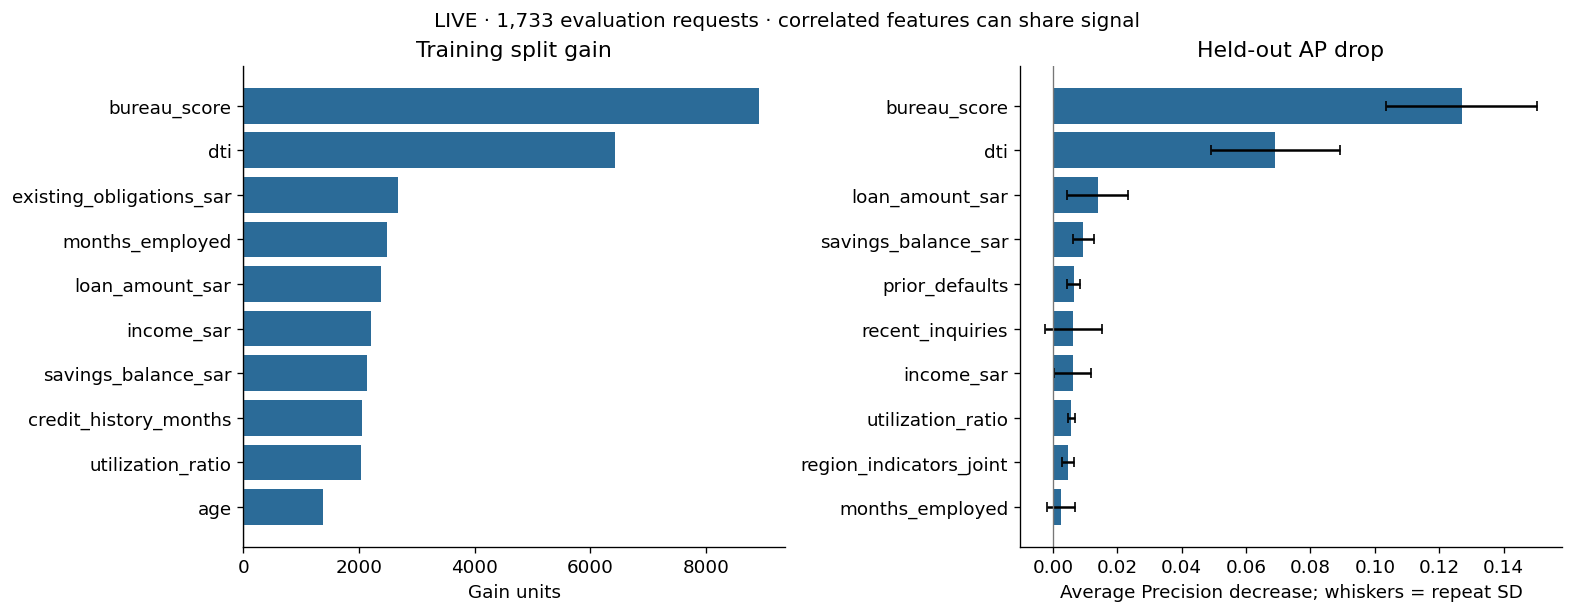

In [3]:
permutation = permutation_report(model, parts["evaluation"], contract, config)
display(permutation[["feature_group", "mean_ap_drop", "repeat_sd", "training_gain"]].head(10).round(4))
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
for ax, value, title in [(axes[0], "training_gain", "Training split gain"), (axes[1], "mean_ap_drop", "Held-out AP drop")]:
    top = permutation.nlargest(10, value).sort_values(value)
    ax.barh(top.feature_group, top[value], color="#2b6b98",
            xerr=top.repeat_sd if value == "mean_ap_drop" else None, capsize=3)
    ax.axvline(0, color="#777", lw=.8); ax.set_title(title)
    ax.set_xlabel("Gain units" if value == "training_gain" else "Average Precision decrease; whiskers = repeat SD")
fig.suptitle(f"LIVE · {len(evaluation):,} evaluation requests · correlated features can share signal", fontsize=12)
fig.savefig(ARTIFACTS / "permutation_importance.png", bbox_inches="tight"); plt.show()

,feature,mean_absolute_shap_log_odds
4,bureau_score,0.9042
5,dti,0.5437
2,loan_amount_sar,0.3490
10,savings_balance_sar,0.2169
9,existing_obligations_sar,0.2022
8,prior_defaults,0.1830
6,months_employed,0.1584
1,income_sar,0.1549
7,recent_inquiries,0.1492
13,utilization_ratio,0.1287


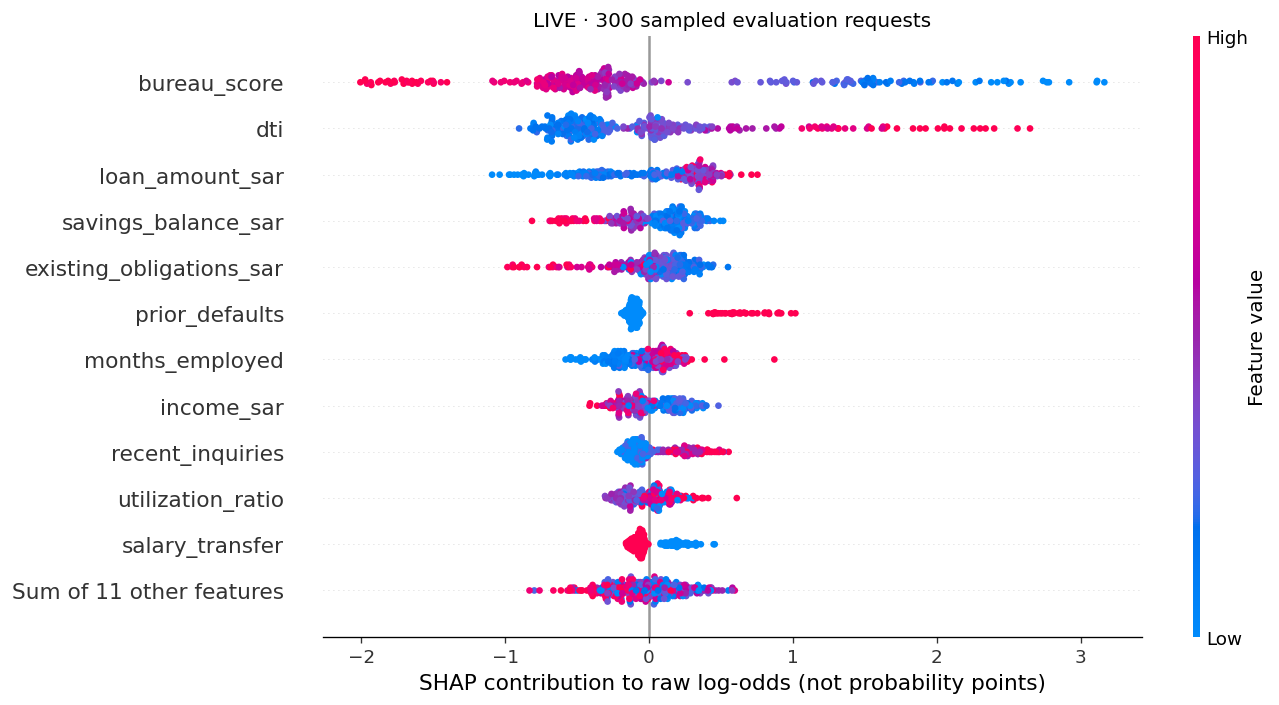

Maximum additivity error: 5.6968318951078345e-15


In [4]:
try:
    if USE_SHAP_EXAMPLE:
        raise ShapBudgetExpired("Educational example requested.")
    shap_arrays, shap_metadata = explain_sample(model, parts["evaluation"], contract, config)
except ShapBudgetExpired:
    shap_arrays, shap_metadata = load_shap_example(ROOT / "data/day4_shap_example.npz",
        ROOT / "data/day4_shap_example.json", model, parts["evaluation"], contract, ASSESSMENT_MODE)

import shap
EXPLANATION_SOURCE = shap_metadata["source"]
if EXPLANATION_SOURCE != "LIVE":
    print("EDUCATIONAL_EXAMPLE — مثال موسوم للمناقشة، غير صالح للتسليم كتجربتك. أعد SHAP لاحقًا.")
explanation = shap.Explanation(values=shap_arrays["values"], base_values=shap_arrays["base_values"],
    data=shap_arrays["data"], feature_names=list(shap_arrays["feature_names"]))
shap_global = pd.DataFrame({"feature": shap_arrays["feature_names"],
    "mean_absolute_shap_log_odds": np.abs(shap_arrays["values"]).mean(axis=0)}).sort_values("mean_absolute_shap_log_odds", ascending=False)
display(shap_global.head(10).round(4))
plt.figure()
shap.plots.beeswarm(explanation, max_display=12, show=False, plot_size=(11, 6.5))
plt.xlabel("SHAP contribution to raw log-odds (not probability points)")
plt.title(f"{EXPLANATION_SOURCE} · {len(shap_arrays['application_ids'])} sampled evaluation requests", fontsize=12)
plt.savefig(ARTIFACTS / "shap_beeswarm.png", bbox_inches="tight"); plt.show()
print("Maximum additivity error:", shap_metadata["max_additivity_error"])

TR-009585 | raw score=0.9031 | calibrated probability=0.4795


,feature,value_used,was_imputed,contribution_log_odds,reason_ar
0,bureau_score,497.0000,False,2.269325,استخدم النموذج درجة ائتمانية اصطناعية عند الطل...
1,dti,1.2806,False,1.198145,استخدم النموذج نسبة الالتزام مع القسط المقترح ...
2,loan_amount_sar,93437.2900,False,0.200725,استخدم النموذج مبلغ التمويل المطلوب بالقيمة 93...


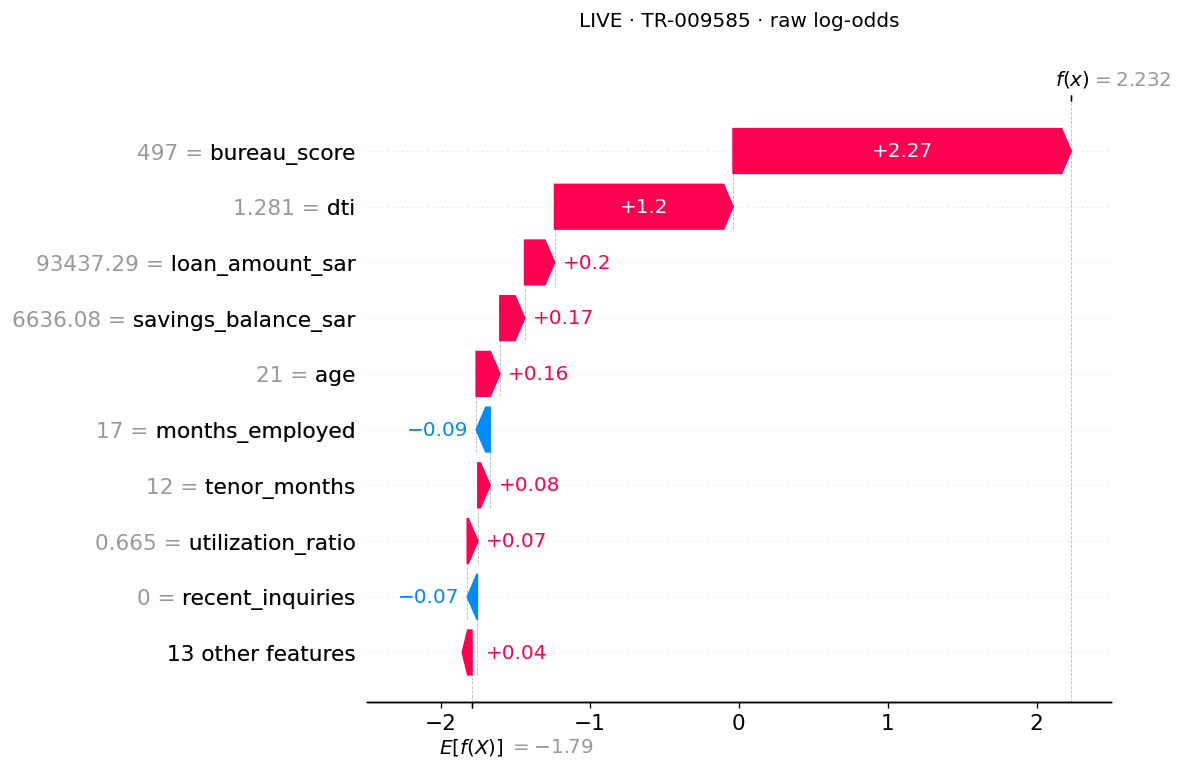

,perturbation,bureau_score_used,raw_probability,calibrated_probability,top_positive_features,shared_top_reasons,reference_reasons,source
0,bureau_score +0,497.0,0.903079,0.479518,bureau_score|dti|loan_amount_sar,3,3,LIVE
1,bureau_score -1,496.0,0.903079,0.479518,bureau_score|dti|loan_amount_sar,3,3,LIVE
2,bureau_score +1,498.0,0.903079,0.479518,bureau_score|dti|loan_amount_sar,3,3,LIVE


In [5]:
local_index = int(np.argmax(shap_arrays["raw_margin"]))
local_id = str(shap_arrays["application_ids"][local_index])
case = parts["evaluation"].set_index("application_id", drop=False).loc[[local_id]]
descriptions = {f["name"]: f["description_ar"] for f in contract["features"]}
reasons = reason_codes(shap_arrays["values"][local_index], shap_arrays["feature_names"],
    shap_arrays["data"][local_index], descriptions)
reasons["application_id"] = local_id
reasons["was_imputed"] = [bool(case.iloc[0][feature] != case.iloc[0][feature]) for feature in reasons.feature]
reasons["source"] = EXPLANATION_SOURCE
raw_local = float(expit(shap_arrays["raw_margin"][local_index]))
cal_local = float(map_probability(raw_local, mapping))
print(f"{local_id} | raw score={raw_local:.4f} | calibrated probability={cal_local:.4f}")
display(reasons[["feature", "value_used", "was_imputed", "contribution_log_odds", "reason_ar"]])
plt.figure()
shap.plots.waterfall(explanation[local_index], max_display=10, show=False)
plt.title(f"{EXPLANATION_SOURCE} · {local_id} · raw log-odds", fontsize=12, pad=45)
plt.savefig(ARTIFACTS / "shap_waterfall.png", bbox_inches="tight"); plt.show()
if EXPLANATION_SOURCE == "LIVE":
    local_checks = local_stability(model, case, contract, mapping)
    local_checks["source"] = "LIVE"
    display(local_checks)
else:
    local_checks = pd.DataFrame(columns=["perturbation", "bureau_score_used", "raw_probability", "calibrated_probability",
        "top_positive_features", "shared_top_reasons", "reference_reasons", "source"])
    print("Local perturbation check skipped in example mode; do not claim it ran.")

,rows,positives,roc_auc,average_precision,brier,ece,log_loss
raw,1733,139,0.770804,0.258677,0.113027,0.146871,0.357993
sigmoid,1733,139,0.770804,0.258677,0.067112,0.022486,0.246749


Measured change (after - before): Brier -0.04592, ECE -0.12438


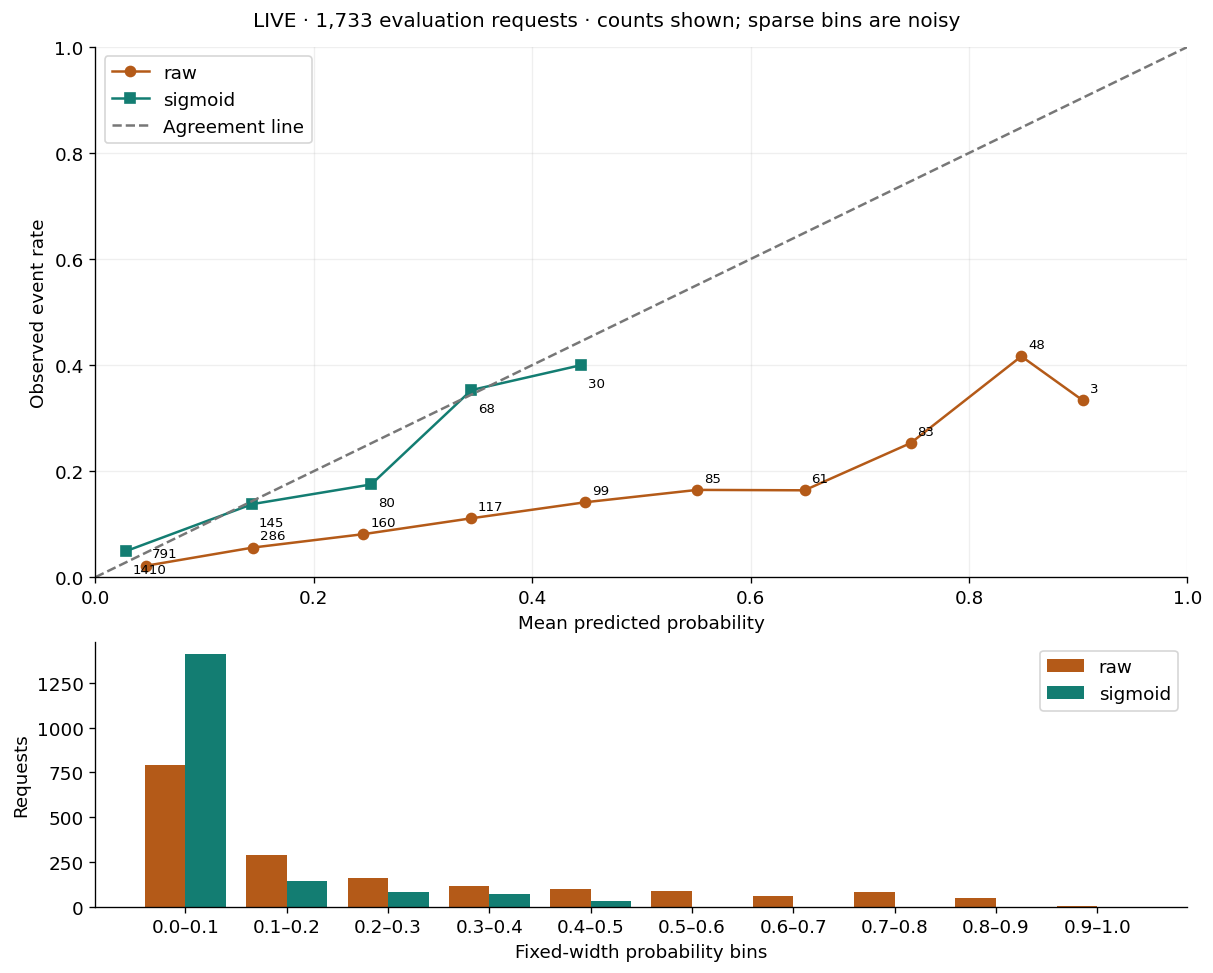

In [6]:
calibration_metrics, bin_tables = {}, []
for label, column in [("raw", "raw_probability"), ("sigmoid", "calibrated_probability")]:
    calibration_metrics[label] = probability_metrics(evaluation[TARGET], evaluation[column])
    table = reliability_table(evaluation[TARGET], evaluation[column]); table["variant"] = label
    bin_tables.append(table)
reliability = pd.concat(bin_tables, ignore_index=True)
display(pd.DataFrame(calibration_metrics).T[["rows", "positives", "roc_auc", "average_precision", "brier", "ece", "log_loss"]].round(5))
brier_delta = calibration_metrics["sigmoid"]["brier"] - calibration_metrics["raw"]["brier"]
ece_delta = calibration_metrics["sigmoid"]["ece"] - calibration_metrics["raw"]["ece"]
print(f"Measured change (after - before): Brier {brier_delta:+.5f}, ECE {ece_delta:+.5f}")
fig, axes = plt.subplots(2, 1, figsize=(10, 8), layout="constrained", gridspec_kw={"height_ratios": [2, 1]})
for label, color, marker in [("raw", "#b45a18", "o"), ("sigmoid", "#137d72", "s")]:
    bins = reliability[reliability.variant == label]; nonempty = bins[bins['count'] > 0]
    axes[0].plot(nonempty.mean_probability, nonempty.observed_rate, marker=marker, color=color, label=label)
    for row in nonempty.itertuples():
        axes[0].annotate(str(row.count), (row.mean_probability, row.observed_rate), xytext=(4, 5 if label == "raw" else -13), textcoords="offset points", fontsize=8)
    positions = bins['bin'] + (-.2 if label == "raw" else .2)
    axes[1].bar(positions, bins['count'], width=.4, color=color, label=label)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="#777", label="Agreement line")
axes[0].set(xlim=(0, 1), ylim=(0, 1), xlabel="Mean predicted probability", ylabel="Observed event rate")
axes[0].legend(); axes[0].grid(alpha=.2)
axes[1].set(xticks=np.arange(10), xticklabels=[f"{i/10:.1f}–{(i+1)/10:.1f}" for i in range(10)], ylabel="Requests", xlabel="Fixed-width probability bins")
axes[1].legend()
fig.suptitle(f"LIVE · {len(evaluation):,} evaluation requests · counts shown; sparse bins are noisy", fontsize=12)
fig.savefig(ARTIFACTS / "reliability_curve.png", bbox_inches="tight"); plt.show()

,period,variant,rows,positives,average_precision,brier,ece
0,2024Q3,raw,836,78,0.27457,0.11528,0.13397
1,2024Q3,sigmoid,836,78,0.27457,0.07760,0.03229
2,2024Q4,raw,897,61,0.27050,0.11093,0.15890
3,2024Q4,sigmoid,897,61,0.27050,0.05734,0.02434


Paired customer-cluster 95% percentile intervals:


,lower,upper
raw_ap,0.197442,0.337854
calibrated_ap,0.197442,0.337854
brier_change,-0.054177,-0.037409


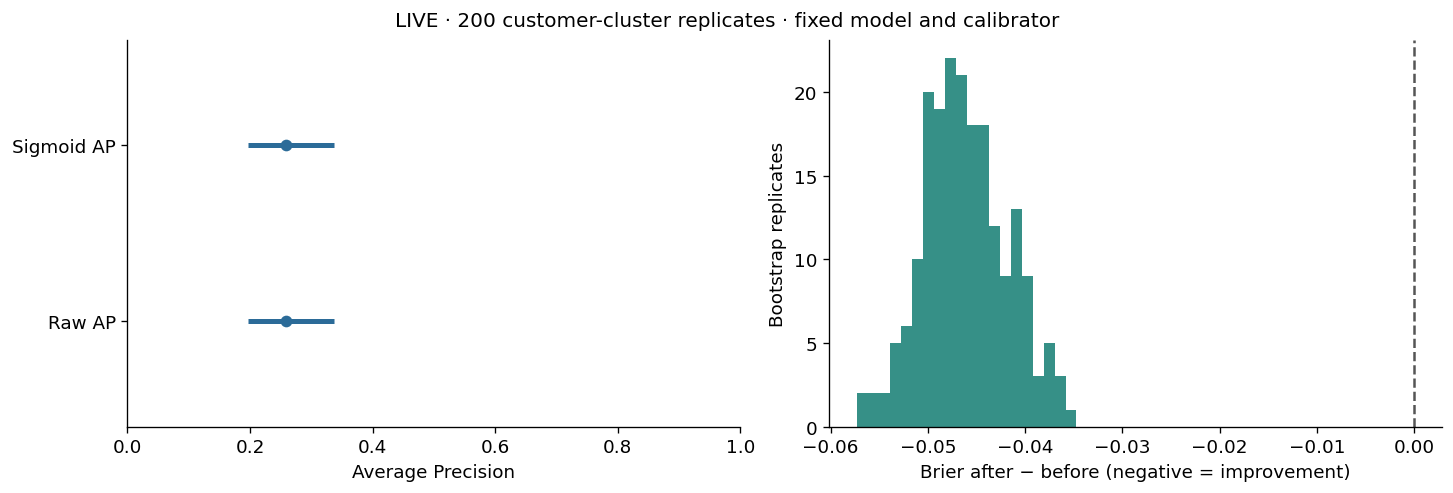

In [7]:
bootstrap, stability_summary = cluster_bootstrap(evaluation, config)
period_rows = []
for period, group in evaluation.groupby(pd.to_datetime(evaluation.application_date).dt.to_period("Q").astype(str)):
    for variant, column in [("raw", "raw_probability"), ("sigmoid", "calibrated_probability")]:
        period_rows.append({"period": period, "variant": variant, **probability_metrics(group[TARGET], group[column])})
period_metrics = pd.DataFrame(period_rows)
display(period_metrics[["period", "variant", "rows", "positives", "average_precision", "brier", "ece"]].round(5))
stability_summary["period_ap_sample_sd"] = {v: float(g.average_precision.std(ddof=1)) for v, g in period_metrics.groupby("variant")}
print("Paired customer-cluster 95% percentile intervals:")
display(pd.DataFrame({key: stability_summary[key] for key in ("raw_ap", "calibrated_ap", "brier_change")}).T)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for i, key in enumerate(("raw_ap", "calibrated_ap")):
    interval = stability_summary[key]
    point = calibration_metrics["raw" if i == 0 else "sigmoid"]["average_precision"]
    if interval is not None:
        axes[0].hlines(i, interval["lower"], interval["upper"], color="#2b6b98", lw=3)
    axes[0].plot(point, i, "o", color="#2b6b98")
axes[0].set(yticks=[0, 1], yticklabels=["Raw AP", "Sigmoid AP"], xlabel="Average Precision", xlim=(0, 1), ylim=(-.6, 1.6))
axes[1].hist(bootstrap.brier_change, bins=20, color="#137d72", alpha=.85)
axes[1].axvline(0, color="#555", linestyle="--"); axes[1].set(xlabel="Brier after − before (negative = improvement)", ylabel="Bootstrap replicates")
fig.suptitle(f"LIVE · {stability_summary['valid']} customer-cluster replicates · fixed model and calibrator", fontsize=12)
fig.savefig(ARTIFACTS / "stability_summary.png", bbox_inches="tight"); plt.show()

,threshold,flagged,fn,fp,loss_units,capacity,feasible,calibrated_threshold,selection_role
0,0.588195,68,34,47,387.0,70,True,0.17331,policy


,period,rows,capacity,risk_flags,near_threshold,candidate_review,risk_within_capacity,candidate_within_capacity,loss_units
0,2024Q3,836,100,97,23,109,True,False,536.0
1,2024Q4,897,107,109,21,122,False,False,444.0


CAPACITY_REVIEW_REQUIRED | Do not retune on evaluation.


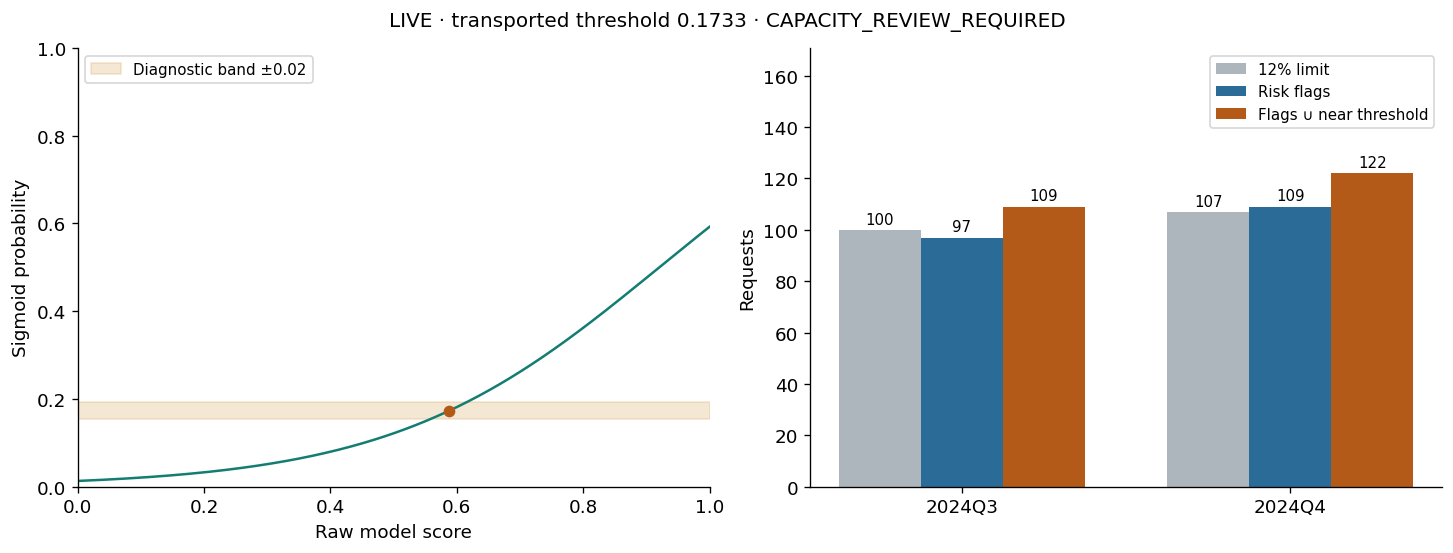

In [8]:
review_flags, capacity_audit, review_band = review_audit(evaluation, chosen_policy["threshold"],
    calibrated_threshold, config.review_half_width)
policy_status = "CAPACITY_REVIEW_REQUIRED" if not capacity_audit.candidate_within_capacity.all() else "WITHIN_OBSERVED_CAPACITY"
display(pd.DataFrame([{**chosen_policy, "calibrated_threshold": calibrated_threshold, "selection_role": "policy"}]))
display(capacity_audit)
print(policy_status, "| Do not retune on evaluation.")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
grid = np.linspace(0, 1, 300)
axes[0].plot(grid, map_probability(grid, mapping), color="#137d72")
axes[0].axhspan(review_band['lower'], review_band['upper'], color="#d7a354", alpha=.25, label="Diagnostic band ±0.02")
axes[0].plot(chosen_policy['threshold'], calibrated_threshold, 'o', color="#b45a18")
axes[0].set(xlim=(0, 1), ylim=(0, 1), xlabel="Raw model score", ylabel="Sigmoid probability")
axes[0].legend(loc="upper left", fontsize=9)
x = np.arange(len(capacity_audit))
for offset, column, label, color in [(-.25, 'capacity', '12% limit', '#aeb6bd'), (0, 'risk_flags', 'Risk flags', '#2b6b98'), (.25, 'candidate_review', 'Flags ∪ near threshold', '#b45a18')]:
    bars = axes[1].bar(x+offset, capacity_audit[column], width=.25, label=label, color=color)
    axes[1].bar_label(bars, padding=2, fontsize=9)
axes[1].set(xticks=x, xticklabels=capacity_audit.period, ylabel="Requests", ylim=(0, capacity_audit.candidate_review.max()*1.4))
axes[1].legend(fontsize=9)
fig.suptitle(f"LIVE · transported threshold {calibrated_threshold:.4f} · {policy_status}", fontsize=12)
fig.savefig(ARTIFACTS / "review_zone.png", bbox_inches="tight"); plt.show()

In [10]:
responses = {
    "global_local": "Globally, permutation importance on 1,733 evaluation requests shows bureau_score (AP drop 0.127) and dti (0.069) dominate, and mean |SHAP| agrees (0.90 and 0.54 log-odds). Locally, request TR-009585 is driven by a low bureau_score of 497 (+2.27) and a high dti of 1.28 (+1.20). Global importance describes the whole sample; a local explanation describes one request and can differ from the global ranking.",
    "output_units": "SHAP values are in raw log-odds, not probability points: they add up from the base value E[f(X)] = -1.79 to f(x) = 2.23 for this request (additivity error 5.7e-15). A +2.27 contribution is not +227% or +2.27 percentage points. Probabilities are shown separately: raw score 0.903, calibrated 0.48.",
    "reason_limits": "SHAP explains the fitted model, not real-world causes, and correlated features (income, obligations, savings) can share or swap credit. Gain in training and held-out permutation rank features differently (months_employed is high in gain but near zero in permutation). Reason codes are not proof of fairness or legal compliance, and the data are synthetic.",
    "calibration_evidence": "Sigmoid calibration was learned only on the Jul-Sep 2023 calibration rows and measured on evaluation. Brier fell from 0.113 to 0.067 and ECE from 0.147 to 0.022, while ROC-AUC (0.771) and AP (0.259) did not change, because calibration changes probability values, not ranking. Bins above 0.4 hold few requests, so they are noisy.",
    "stability": "With 200 customer-cluster bootstrap replicates, the 95% interval for AP is 0.197 to 0.338, so a single AP value is uncertain. The Brier change stays negative in the whole interval (-0.054 to -0.037), and both evaluation quarters improved (ECE 0.134 to 0.032 and 0.159 to 0.024). The local top three reasons stayed the same when bureau_score moved by +/-1.",
    "review_capacity": "The policy threshold (raw 0.588, calibrated 0.173) was feasible on policy rows (68 flags vs capacity 70). On evaluation it flags 97 of 100 allowed in 2024Q3 but 109 of 107 in 2024Q4, and the +/-0.02 review band raises this to 109 and 122. Status is CAPACITY_REVIEW_REQUIRED: the threshold must not be retuned on evaluation data; the overrun must be escalated and monitored."
}
checkpoint = reflection_check(responses, EXPLANATION_SOURCE)
print(checkpoint["status"], "| Fields to complete:", checkpoint["missing"])

READY_FOR_REVIEW | Fields to complete: []


In [11]:
def json_safe(value):
    if isinstance(value, dict): return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, np.ndarray)): return [json_safe(v) for v in value]
    if isinstance(value, (np.integer,)): return int(value)
    if isinstance(value, (np.bool_,)): return bool(value)
    if isinstance(value, (float, np.floating)): return float(value) if np.isfinite(value) else None
    return value

technical_status = "TECHNICAL_READY" if EXPLANATION_SOURCE == "LIVE" else "EXAMPLE_ONLY_NOT_SUBMITTABLE"
calibration_payload = {"source": "LIVE", "evaluation_role": "evaluation", "metrics": calibration_metrics,
    "mapping": mapping, "policy_selection": chosen_policy, "calibrated_threshold": calibrated_threshold,
    "review_band": review_band, "capacity_status": policy_status, "brier_change": brier_delta, "ece_change": ece_delta,
    "prior_course_exposure": True, "not_a_final_untouched_test": True}
run = {"technical_status": technical_status, "learner_status": checkpoint["status"],
    "explanation_source": EXPLANATION_SOURCE, "model_calibration_source": "LIVE", "config": asdict(config),
    "assessment_mode": ASSESSMENT_MODE, "lab_revision": LAB_REVISION, "support_sha256": SUPPORT_HASHES,
    "previous_support": PREVIOUS_SUPPORT, "data_revision": COURSE_REVISION, "python": platform.python_version(),
    "elapsed_seconds": round(time.perf_counter()-RUN_STARTED, 2), "capacity_status": policy_status,
    "challenge_used_for_modeling": False, "no_automatic_grade": True}
csv_outputs = {"day4_roles.csv": assignments, "day4_predictions.csv": predictions,
    "permutation_importance.csv": permutation, "day4_shap_global.csv": shap_global.assign(source=EXPLANATION_SOURCE),
    "day4_reason_codes.csv": reasons, "day4_local_stability.csv": local_checks,
    "day4_reliability_bins.csv": reliability, "day4_period_metrics.csv": period_metrics,
    "day4_bootstrap.csv": bootstrap, "day4_policy_sweep.csv": policy_sweep,
    "day4_review_flags.csv": review_flags, "day4_capacity.csv": capacity_audit}
for filename, table in csv_outputs.items(): table.to_csv(ARTIFACTS / filename, index=False)
np.savez_compressed(ARTIFACTS / "shap_values_sample.npz", **shap_arrays)
model.named_steps["model"].booster_.save_model(str(ARTIFACTS / "day4_model.txt"))
json_outputs = {"calibration_metrics.json": calibration_payload, "day4_shap_metadata.json": shap_metadata,
    "day4_stability_summary.json": stability_summary, "day4_provenance.json": provenance,
    "day4_reflection.json": {"responses": responses, "checkpoint": checkpoint}, "day4_run.json": run}
for filename, payload in json_outputs.items():
    (ARTIFACTS / filename).write_text(json.dumps(json_safe(payload), ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")
answer = lambda key: responses[key].strip() or "[اكتب تفسيرك من نتائجك هنا]"
status_text = "مثال تعليمي غير صالح للتسليم كتجربة شخصية" if EXPLANATION_SOURCE != "LIVE" else ("مسودة — أكمل تفسيرك" if checkpoint['missing'] else "جاهز للمراجعة؛ لا يعني اعتمادًا أو درجة")
reason_text = "\n".join(f"- {r.reason_ar} (SHAP={r.contribution_log_odds:+.4f} log-odds؛ قيمة معوضة: {r.was_imputed})" for r in reasons.itertuples())
capacity_text = "\n".join(f"- {r.period}: السقف {r.capacity}، الإشارات {r.risk_flags}، اتحاد المراجعة {r.candidate_review}." for r in capacity_audit.itertuples())
report = f"""# تقريرك: التفسير والمعايرة — Tamweel Lite

**الحالة:** {status_text}

**مصدر التفسير:** {EXPLANATION_SOURCE}. **النموذج والمعايرة:** LIVE. **السعة:** {policy_status}.

## النموذج والأدوار
LightGBM موزون، {config.trees} شجرة. الهدف حدث تعثر اصطناعي خلال90 يومًا بعد الطلب. الأدوار منفصلة زمنيًا وبالعملاء: تدريب {len(parts['fit'])}، معايرة {len(parts['calibration'])} ({int(parts['calibration'][TARGET].sum())} موجب)، سياسة {len(parts['policy'])}، تقييم {len(evaluation)}. الفجوات والتداخلات مستبعدة. سبق استخدام بيانات التقييم في الدورة، فهي ليست اختبارًا نهائيًا لم يمسّ.

## التفسير العام والمحلي
Permutation يقيس انخفاضAP على التقييم؛ إشارات المنطقة تُبدّل معًا. SHAP يفسر النموذج الخام بوحدةlog-odds وخلفية مسارات أشجار التدريب. base+sum(SHAP)=raw margin، ثمsigmoid للمجموع فقط. القيم ليست نقاط احتمال ولا تفسيرًا مباشرًا للنموذج المعاير.

{answer('global_local')}

{answer('output_units')}

الطلب الاصطناعي {local_id}: الدرجة الخام {raw_local:.5f} والاحتمال المعاير {cal_local:.5f}. اختير أعلى درجة داخل عينةSHAP دون استخدام النتيجة الفعلية.
{reason_text}

{answer('reason_limits')}

## دليل المعايرة
على {len(evaluation)} صفًا و{int(evaluation[TARGET].sum())} موجب: Brier {calibration_metrics['raw']['brier']:.6f} → {calibration_metrics['sigmoid']['brier']:.6f}؛ ECE {calibration_metrics['raw']['ece']:.6f} → {calibration_metrics['sigmoid']['ece']:.6f}. عشر حاويات متساوية العرض مع أعدادها فيday4_reliability_bins.csv. AP {calibration_metrics['raw']['average_precision']:.6f} → {calibration_metrics['sigmoid']['average_precision']:.6f}؛ ROC-AUC {calibration_metrics['raw']['roc_auc']:.6f} → {calibration_metrics['sigmoid']['roc_auc']:.6f}. هذه نتائج هذه العينة وليست ضمانًا لتحسن مستقبلي.

{answer('calibration_evidence')}

## الاستقرار
{stability_summary['valid']} تكرارbootstrap صالح بسحب العملاء؛ فترات مئينية95% مع تثبيت النموذج والمعاير. لا تشمل تعلم النموذج أو المعايرة أو الانجراف المستقبلي، ولا تصف احتمال فرد. انحرافAP بين ربعي التقييم وصفي فقط. اختبارbureau_score±1 {'نُفذ؛ راجع day4_local_stability.csv' if EXPLANATION_SOURCE == 'LIVE' else 'لم ينفذ في وضع المثال'}.

{answer('stability')}

## العتبة ومنطقة المراجعة
العتبة الخام {chosen_policy['threshold']!r} اختيرت علىpolicy بخسارة10×FN+FP وسقف12% ثم نُقلت إلى {calibrated_threshold!r}. لم تعدل باستخدام التقييم. المنطقة[{review_band['lower']:.5f}, {review_band['upper']:.5f}] تشخيصية بعرض±0.02 وليست فترة ثقة. الاتحاد يحسب الطلب مرة واحدة.
{capacity_text}

{answer('review_capacity')}

عند تجاوز السعة، وثّق الحاجة إلى تصميم سياسة جديدة على بيانات تطوير وتقييمها بدليل جديد. لا ترفع السقف ولا تقص الحالات بعد رؤية النتيجة. التفسير ليس سببية أو شهادة عدالة، والخسارة وحدات تعليمية لا رسوم أو خصم درجات. لا يستخدم هذا التمرين لتمويل حقيقي.
"""
(REPORTS / "INTERPRETABILITY_REPORT.md").write_text(report, encoding="utf-8")
figures = ["permutation_importance.png", "shap_beeswarm.png", "shap_waterfall.png", "reliability_curve.png", "stability_summary.png", "review_zone.png"]
artifact_files = list(csv_outputs) + list(json_outputs) + figures + ["environment.json", "shap_values_sample.npz", "day4_model.txt"]
with zipfile.ZipFile(ARTIFACTS / "day4_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as bundle:
    for filename in artifact_files: bundle.write(ARTIFACTS / filename, "artifacts/" + filename)
    bundle.write(REPORTS / "INTERPRETABILITY_REPORT.md", "reports/INTERPRETABILITY_REPORT.md")
print(f"{technical_status} | {checkpoint['status']} | {EXPLANATION_SOURCE} | CPU")
print(f"Saved {len(artifact_files)+1} files in day4_artifacts.zip | {policy_status}")

TECHNICAL_READY | READY_FOR_REVIEW | LIVE | CPU
Saved 28 files in day4_artifacts.zip | CAPACITY_REVIEW_REQUIRED


### Day 4 summary
**Goal:** explain what the model uses and test whether its probabilities are trustworthy.

- **Roles:** fit (2,516) · calibration Jul–Sep 2023 (584) · policy Jan–Mar 2024 (589) · evaluation Jul–Dec 2024 (1,733); everything frozen before evaluation.
- **Drivers:** bureau_score (permutation AP drop 0.127, mean |SHAP| 0.90) and dti (0.069, 0.54) dominate.
- **Local example:** TR-009585, raw score 0.903 → calibrated 0.48; low bureau_score 497 (+2.27 log-odds) and high dti 1.28 (+1.20).

| Probabilities | ROC-AUC | AP | Brier | ECE |
|---|---|---|---|---|
| Raw | 0.771 | 0.259 | 0.113 | 0.147 |
| **Sigmoid** | 0.771 | 0.259 | **0.067** | **0.022** |

- **Stability:** AP 95% interval 0.197–0.338; Brier improvement stays negative (−0.054 to −0.037).
- **Capacity:** threshold 0.173 (calibrated) fits policy rows but flags 109 of 107 allowed in 2024Q4 → **CAPACITY_REVIEW_REQUIRED**; not retuned on evaluation.

---
# Day 5 – Final Model & Delivery
*Source notebook: `05_final_model.ipynb`*

# Day 5 · Ensemble decision, final model and delivery

In [12]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
PREVIOUS_SUPPORT = {
 "scripts/day2_validation.py": ("1e1da4acbee8941bef07245b259fb6c27ced4ad7", "d2fd0353330c3629bdaed6c570528792955fce232540a85d33532a9432522f43"),
 "scripts/day3_decision.py": ("c2dc52e129878d0d487db1874891c658de7c4d0d", "40f176633c91fc530db222978bc44495a401b888b1ce448728948f7ae0ca9e12"),
 "scripts/day4_trust.py": ("4f6892d5c02923b5f8e3c78f4fcead73b043570f", "7e0f54bdbed94b28d09cddd02ce0ba0471d5046f05c7b70589e3e4be9902f20c")}
for relative, (revision, digest) in PREVIOUS_SUPPORT.items():
    fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{revision}/{relative}", ROOT / relative, digest)
LAB_REVISION = "f486fc50dd9ac8403016facc58cf6a62beb4abf4"
SUPPORT_HASHES = {'scripts/day5_final.py': '71553cffc66f972e77d470a347cae40e4ca2802026535b48cb40168a59362b10', 'scripts/day5_delivery.py': 'eba5b5820550b44ccca2cf7f5d56a826c015de552e5db8d7e4c27a6e956ecd21', 'scripts/inference.py': 'abf1af0bca47bcd08e66f8218276773d39083e6f42f42caeea5d8b2db70c0a6a', 'scripts/replay_final.py': 'adcb2e40aff819439068cd7a2aca9fcb6f8632b0c551a9d04f7bd63efc8506fb', 'scripts/rebuild_final.py': 'ac18b78160dbc33b720f3e1038667110760832c095e23c1ea7f909d4c5760dfd', 'data/tamweel_oof_matrix.csv': 'f8c9429c7eed015d53978fba93b4b32ed3266fa15b63471b03881ab5c09804b5', 'data/day5_oof_example.json': '9edcb173ab5aa504af3ef79c4f3371cd285fa4b171be1bcc6dd9da1d7fb0394d', 'presentation/FINAL_PRESENTATION_TEMPLATE.md': '8d3df570727b18db097c9c78ed518ac09bd8766dbdba2817ae8883e43ed5de39', 'presentation/FINAL_PRESENTATION_GUIDE.md': '1d24149ef2e56df0a6c44e000157135904b8ba3d252445e4367a6de547c87b19'}
for relative, digest in SUPPORT_HASHES.items():
    fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/{relative}", ROOT / relative, digest)
print("Day 5 setup verified | إعداد اليوم الخامس جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.16 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 5 setup verified | إعداد اليوم الخامس جاهز


In [13]:
import json, platform, time, zipfile
from dataclasses import asdict
from hashlib import sha256
import numpy as np
import pandas as pd
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, FileLink
from data_checks import validate_frame
from day5_final import (BASE, ENSEMBLES, TARGET, FinalConfig, EnsembleBudgetExpired, split_final_roles,
    nested_comparison, load_example, worth_it, selected_oof, fit_final, export_model,
    predict_final, transport_threshold, apply_batch_policy, write_json)
from day3_decision import CostPolicy, threshold_sweep, select_threshold, region_audit, period_audit
from day4_trust import probability_metrics, reliability_table, map_probability
from day5_delivery import (RESPONSES, reflection_check, import_daily_evidence, evidence_status,
    validate_submission, replay_submission, create_bundle, verify_bundle)

STARTED = time.perf_counter()
contract = json.loads((ROOT / "data/data_contract.json").read_text(encoding="utf-8"))
train = pd.read_csv(ROOT / "data/tamweel_train.csv")
challenge = pd.read_csv(ROOT / "data/tamweel_challenge.csv")
validate_frame(train, contract, "train"); validate_frame(challenge, contract, "challenge")
assert not set(train.customer_id) & set(challenge.customer_id)
FAST_MODE, FULL_MODE = True, False
assert FAST_MODE != FULL_MODE
config = FinalConfig() if FAST_MODE else FinalConfig(trees=160, seconds=240)
USE_OOF_EXAMPLE = False  # For discussion only; cannot export a submission.
ASSESSMENT_MODE = os.environ.get("ASSESSMENT_MODE", "0") == "1"
pool, calibration, roles = split_final_roles(train)
ARTIFACTS, REPORTS, SUBMISSION = ROOT / "artifacts", ROOT / "reports", ROOT / "submission"
for folder in (ARTIFACTS, REPORTS, SUBMISSION): folder.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi":120,"font.size":11,"axes.spines.top":False,"axes.spines.right":False})
display(pd.DataFrame([{"role":name,"rows":len(frame),"customers":frame.customer_id.nunique(),
    "positives":int(frame[TARGET].sum()),"first_date":frame.application_date.min(),"last_date":frame.application_date.max()}
    for name,frame in [("fit + selection",pool),("calibration only",calibration)]]))
print("Excluded rows:", int(roles.role.str.startswith("excluded").sum()))

,role,rows,customers,positives,first_date,last_date
0,fit + selection,6576,3931,537,2022-01-01,2024-04-01
1,calibration only,836,788,78,2024-07-01,2024-09-30


Excluded rows: 2588


In [14]:
try:
    if USE_OOF_EXAMPLE:
        raise EnsembleBudgetExpired("Educational OOF example requested.")
    oof, fold_scores, oof_provenance = nested_comparison(pool, contract, config)
except EnsembleBudgetExpired:
    oof, fold_scores, oof_provenance = load_example(ROOT / "data/tamweel_oof_matrix.csv",
        ROOT / "data/day5_oof_example.json", pool, config, assessment_mode=ASSESSMENT_MODE)
SOURCE = oof.source.iloc[0]
if SOURCE != "LIVE": print("EDUCATIONAL_EXAMPLE — للمناقشة فقط، دون نموذج نهائي أو تسليم.")
display(oof[["application_id","fold",*BASE,*ENSEMBLES]].head().round(4))
print(f"{SOURCE}: {len(oof):,} OOF rows across three forward periods; warm-up rows have no outer OOF.")

,application_id,fold,LightGBM,XGBoost,Logistic,Equal,Weighted,Stack
0,TR-001160,1,0.0321,0.0444,0.0467,0.0410,0.0461,0.0684
1,TR-003137,1,0.1149,0.1798,0.1547,0.1498,0.1610,0.1085
2,TR-004529,1,0.0457,0.0854,0.0887,0.0733,0.0879,0.0796
3,TR-004666,1,0.0123,0.0150,0.0062,0.0112,0.0084,0.0593
4,TR-008372,1,0.0373,0.0538,0.0336,0.0416,0.0387,0.0674


LIVE: 2,155 OOF rows across three forward periods; warm-up rows have no outer OOF.


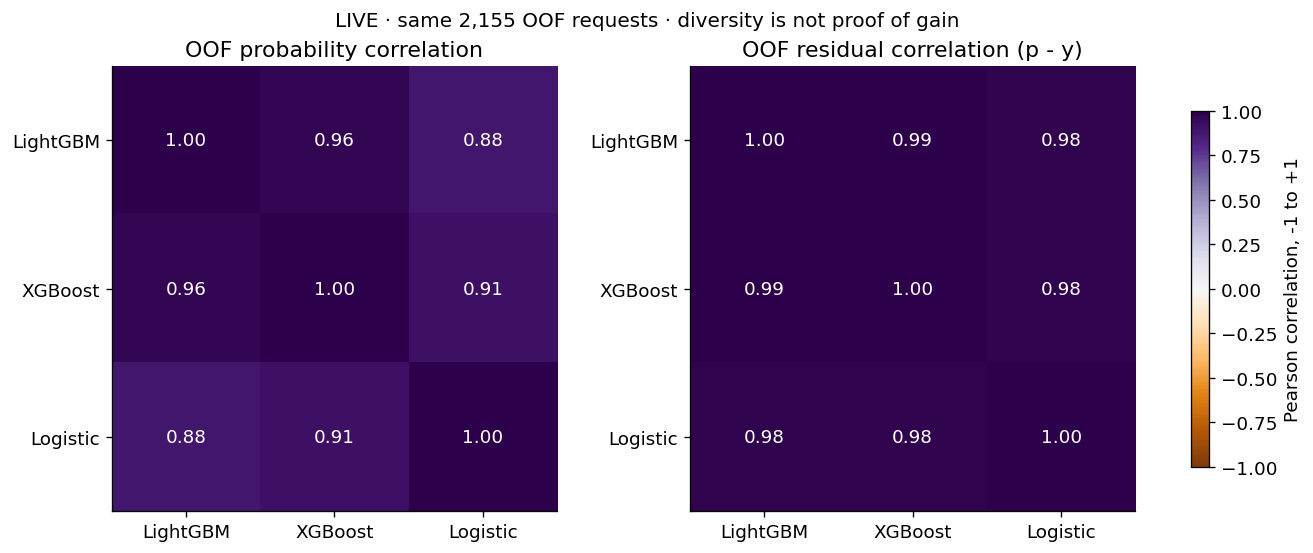

In [15]:
correlation = oof[list(BASE)].corr()
residual_correlation = oof[list(BASE)].sub(oof[TARGET], axis=0).corr()
fig, axes = plt.subplots(1,2,figsize=(11,4.5),layout="constrained")
for ax, table, title in [(axes[0],correlation,"OOF probability correlation"),(axes[1],residual_correlation,"OOF residual correlation (p - y)")]:
    im = ax.imshow(table, vmin=-1, vmax=1, cmap="PuOr")
    ax.set_xticks(range(3),BASE); ax.set_yticks(range(3),BASE); ax.set_title(title)
    for i in range(3):
        for j in range(3):
            value=table.iloc[i,j]
            ax.text(j,i,f"{value:.2f}",ha="center",va="center",color="white" if abs(value)>.6 else "#222")
fig.colorbar(im,ax=axes,shrink=.8,label="Pearson correlation, -1 to +1")
fig.suptitle(f"{SOURCE} · same {len(oof):,} OOF requests · diversity is not proof of gain",fontsize=12)
fig.savefig(ARTIFACTS / "day5_diversity.png",bbox_inches="tight"); plt.show()

,candidate,mean_ap,fold_sd,mean_brier,mean_ece,lift_vs_single,passes_gate
0,LightGBM,0.34549,0.04348,0.06608,0.02311,-0.04617,False
1,XGBoost,0.35263,0.02904,0.06566,0.02276,-0.03903,False
2,Logistic,0.39166,0.02981,0.06327,0.01882,0.00000,False
3,Equal,0.37170,0.03258,0.06435,0.02038,-0.01996,False
4,Weighted,0.38942,0.02906,0.06332,0.01772,-0.00224,False
5,Stack,0.38314,0.02949,0.06603,0.03106,-0.00852,False


KEEP SINGLE → Logistic


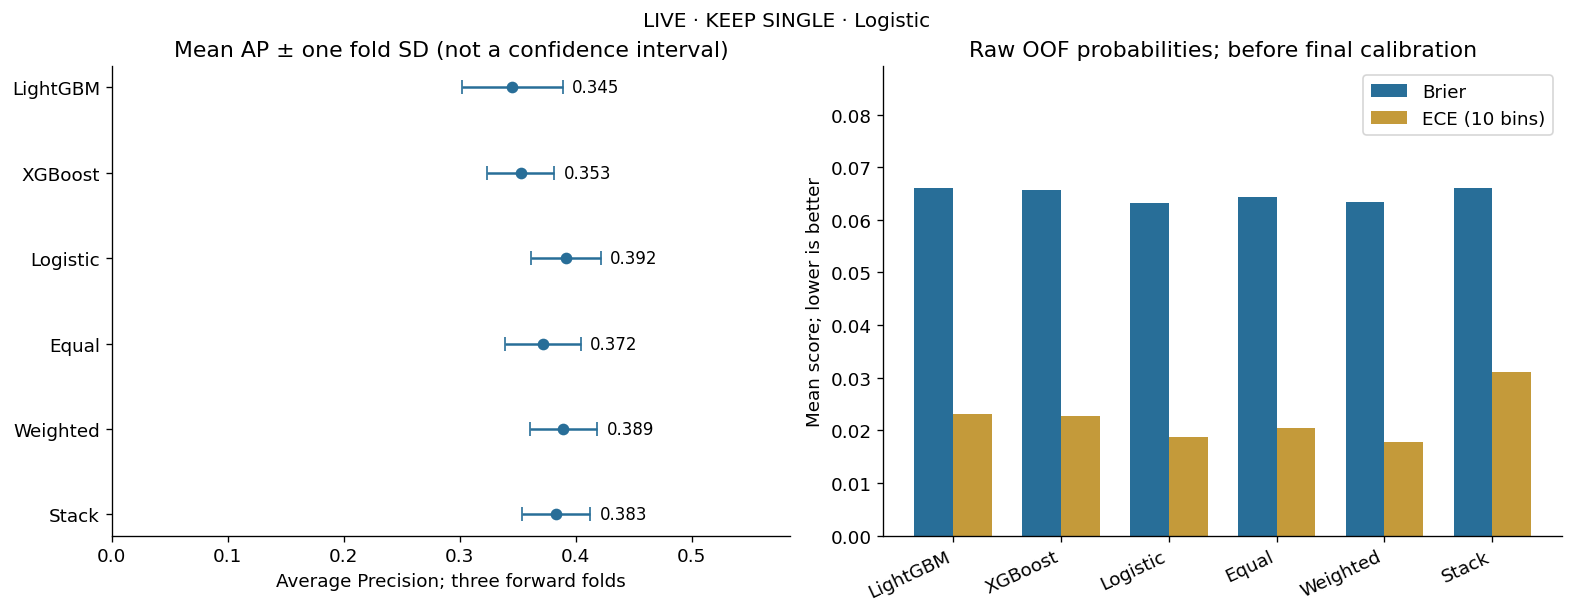

In [16]:
comparison, gate = worth_it(fold_scores, config)
display(comparison.round(5)); print(gate["decision"], "→", gate["chosen"])
fig, axes = plt.subplots(1,2,figsize=(13,5),layout="constrained")
order=list(BASE+ENSEMBLES)
for i,name in enumerate(order):
    row=comparison.set_index("candidate").loc[name]
    axes[0].errorbar(row.mean_ap,i,xerr=row.fold_sd,fmt="o",color="#286e98",capsize=4)
    axes[0].text(row.mean_ap+row.fold_sd+.008,i,f"{row.mean_ap:.3f}",va="center",fontsize=10)
axes[0].set_yticks(range(6),order); axes[0].invert_yaxis(); axes[0].set_xlim(0,min(1,comparison.mean_ap.max()+comparison.fold_sd.max()+.15))
axes[0].set_title("Mean AP ± one fold SD (not a confidence interval)"); axes[0].set_xlabel("Average Precision; three forward folds")
x=np.arange(6)
axes[1].bar(x-.18,comparison.mean_brier,.36,label="Brier",color="#286e98")
axes[1].bar(x+.18,comparison.mean_ece,.36,label="ECE (10 bins)",color="#c49a3a")
axes[1].set_xticks(x,order,rotation=25,ha="right"); axes[1].set_ylabel("Mean score; lower is better")
axes[1].set_title("Raw OOF probabilities; before final calibration"); axes[1].legend()
axes[1].set_ylim(0, max(comparison.mean_brier.max(),comparison.mean_ece.max())*1.35)
fig.suptitle(f"{SOURCE} · {gate['decision']} · {gate['chosen']}",fontsize=12)
fig.savefig(ARTIFACTS / "day5_ensemble_comparison.png",bbox_inches="tight"); plt.show()

,threshold,tp,fp,fn,tn,flagged,flag_fraction,recall,precision,false_positive_rate,accuracy,loss_units,loss_units_per_10000,capacity_feasible,max_period_flag_fraction,rows,source
0,0.16892,84,161,95,1815,245,0.11369,0.46927,0.34286,0.08148,0.88121,1111.0,5155.45244,True,0.11749,2155,LIVE


,region,rows,negatives,positives,flagged,false_positives,true_positives,false_positive_rate,recall,low_negative_support,source
0,central,537,489,48,63,39,24,0.0798,0.5000,False,LIVE
1,western,533,486,47,71,50,21,0.1029,0.4468,False,LIVE
2,eastern,542,507,35,48,32,16,0.0631,0.4571,False,LIVE
3,other,543,494,49,63,40,23,0.0810,0.4694,False,LIVE


,false_negative_cost,false_positive_cost,fixed_threshold,loss_units
0,8,1,0.168922,921
1,10,1,0.168922,1111
2,12,1,0.168922,1301


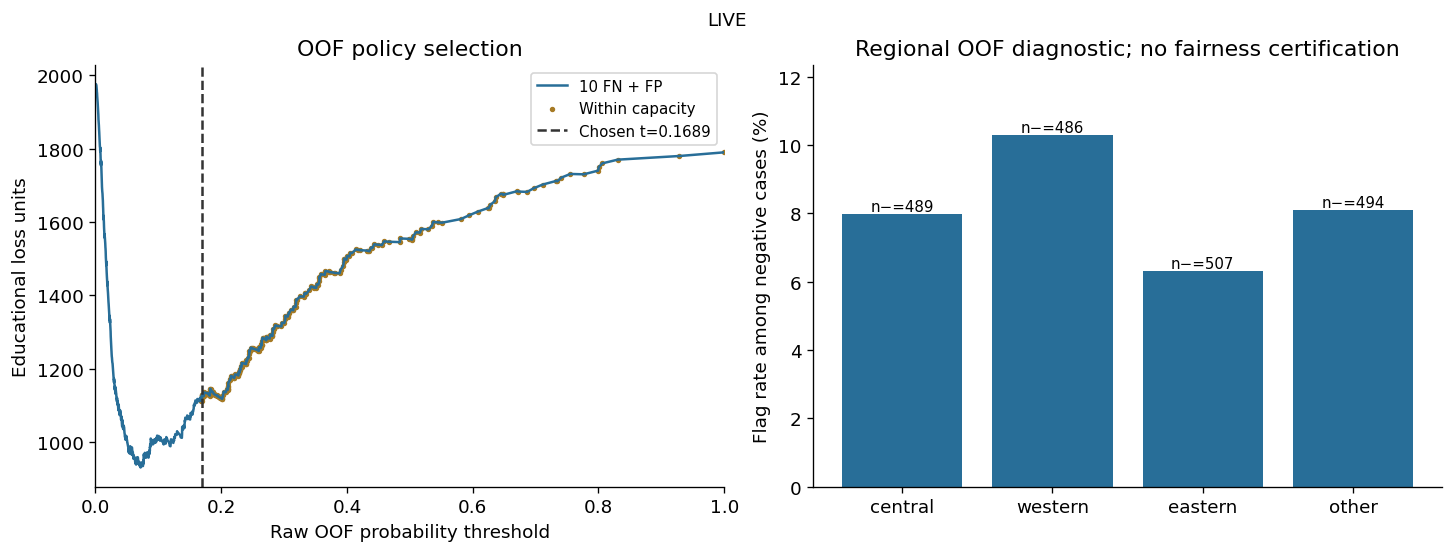

In [17]:
policy = CostPolicy()
selected = selected_oof(oof, gate["chosen"])
sweep = threshold_sweep(selected, policy)
threshold_choice = select_threshold(sweep)
raw_threshold = float(threshold_choice["threshold"])
regional, regional_summary = region_audit(selected, raw_threshold)
period_capacity = period_audit(selected, raw_threshold, policy)
sensitivity = pd.DataFrame([{"false_negative_cost":c,"false_positive_cost":1,
    "fixed_threshold":raw_threshold,"loss_units":c*int(threshold_choice["fn"])+int(threshold_choice["fp"])} for c in (8,10,12)])
display(pd.DataFrame([threshold_choice]).round(5)); display(regional.round(4)); display(sensitivity)
fig, axes = plt.subplots(1,2,figsize=(12,4.5),layout="constrained")
axes[0].plot(sweep.threshold,sweep.loss_units,color="#286e98",label="10 FN + FP")
feasible=sweep[sweep.capacity_feasible]
axes[0].scatter(feasible.threshold,feasible.loss_units,s=5,color="#a67a24",label="Within capacity")
axes[0].axvline(raw_threshold,color="#333",ls="--",label=f"Chosen t={raw_threshold:.4f}")
axes[0].set(xlim=(0,1),xlabel="Raw OOF probability threshold",ylabel="Educational loss units",title="OOF policy selection"); axes[0].legend(fontsize=9)
axes[1].bar(regional.region,regional.false_positive_rate*100,color="#286e98")
axes[1].set(ylabel="Flag rate among negative cases (%)",title="Regional OOF diagnostic; no fairness certification")
for i,r in regional.iterrows(): axes[1].text(i,r.false_positive_rate*100,f"n−={r.negatives}",ha="center",va="bottom",fontsize=9)
axes[1].margins(y=.2)
fig.suptitle(SOURCE,fontsize=11); fig.savefig(ARTIFACTS / "day5_policy_regions.png",bbox_inches="tight"); plt.show()

,rows,positives,prevalence,roc_auc,average_precision,brier,log_loss,ece,bins,binning
raw_fit_diagnostic,836,78,0.093301,0.789037,0.287803,0.076473,0.266489,0.021121,10,"fixed width, [lower, upper); final bin includes 1"
sigmoid_fit_diagnostic,836,78,0.093301,0.789037,0.287803,0.078058,0.277296,0.034871,10,"fixed width, [lower, upper); final bin includes 1"


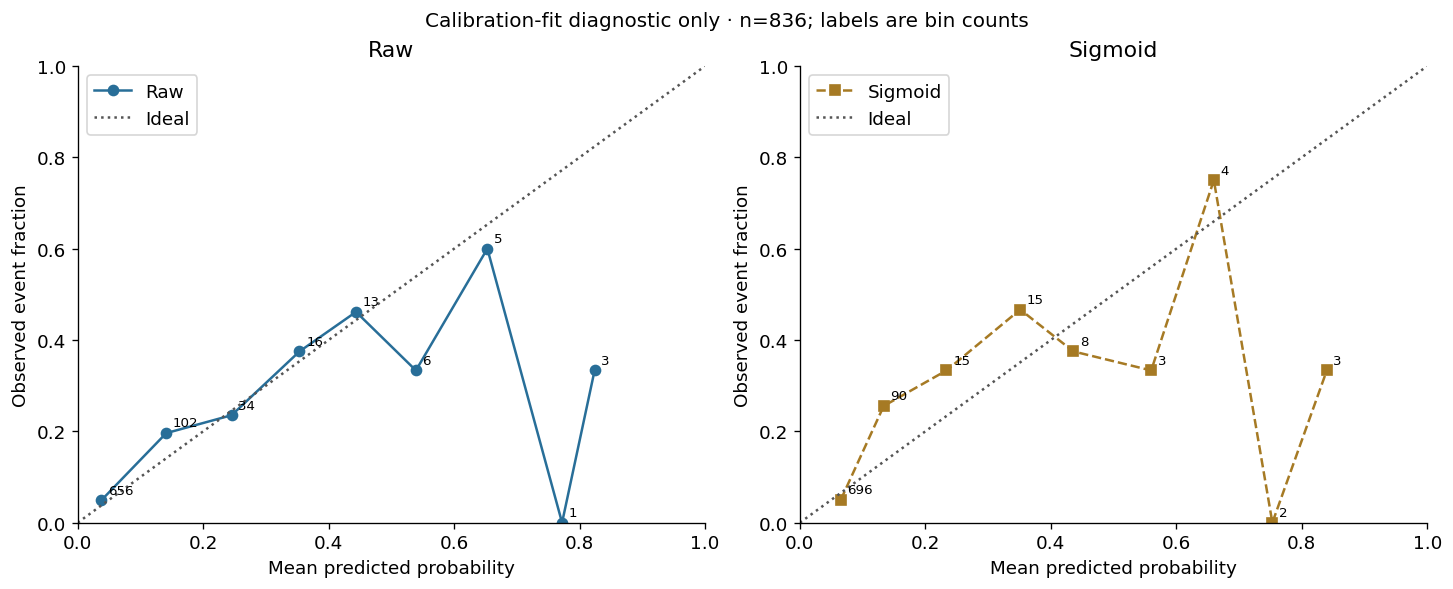

Final model and sigmoid frozen; transported threshold: 0.12225843144286948


In [18]:
if SOURCE == "LIVE":
    final_model, mapping, calibration_predictions, final_provenance = fit_final(pool, calibration, contract, gate["chosen"], config)
    calibrated_threshold = transport_threshold(raw_threshold, mapping)
    final_model_manifest = export_model(final_model, mapping, contract, ARTIFACTS / "final_model")
    calibration_diagnostics = {name:probability_metrics(calibration_predictions[TARGET],calibration_predictions[column])
        for name,column in [("raw_fit_diagnostic","raw_probability"),("sigmoid_fit_diagnostic","probability")]}
    bins = pd.concat([reliability_table(calibration_predictions[TARGET],calibration_predictions[column]).assign(series=name)
        for name,column in [("Raw","raw_probability"),("Sigmoid","probability")]],ignore_index=True)
    display(pd.DataFrame(calibration_diagnostics).T.round(5))
    fig,axes=plt.subplots(1,2,figsize=(12,4.8),layout="constrained")
    for ax,name,style,color in [(axes[0],"Raw","o-","#286e98"),(axes[1],"Sigmoid","s--","#a67a24")]:
        table=bins[(bins.series==name)&(bins['count']>0)]
        ax.plot(table.mean_probability,table.observed_rate,style,label=name,color=color)
        for row in table.itertuples(): ax.annotate(str(row.count),(row.mean_probability,row.observed_rate),xytext=(4,4),textcoords="offset points",fontsize=8)
        ax.plot([0,1],[0,1],":",color="#555",label="Ideal")
        ax.set(xlim=(0,1),ylim=(0,1),xlabel="Mean predicted probability",ylabel="Observed event fraction",title=name)
        ax.legend()
    fig.suptitle(f"Calibration-fit diagnostic only · n={len(calibration)}; labels are bin counts",fontsize=12)
    fig.savefig(ARTIFACTS / "day5_calibration_fit.png",bbox_inches="tight"); plt.show()
    print("Final model and sigmoid frozen; transported threshold:", calibrated_threshold)
else:
    print("EXAMPLE_ONLY_NOT_SUBMITTABLE — final fitting, inference and submission are skipped.")

,application_id,probability,decision
0,CH-000278,0.114104,0
1,CH-001412,0.120922,0
2,CH-001444,0.055587,0
3,CH-002174,0.053426,0
4,CH-002260,0.077174,0


,rows,capacity,threshold_eligible,flagged,removed_by_cap,boundary_score,within_capacity,tie_policy,batch_policy
0,2500,300,330,300,30,0.129908,True,retain entire equal-score blocks; drop boundar...,"threshold first, then probability-descending f..."


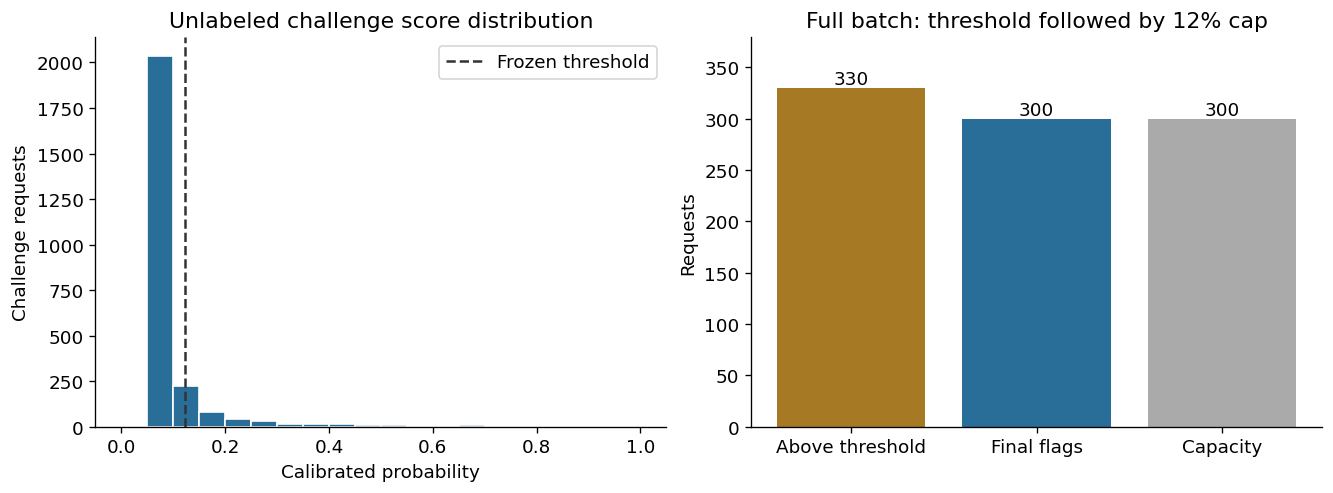

In [20]:
if SOURCE == "LIVE":
    from inference import predict
    predictions = predict(challenge, ARTIFACTS / "final_model")
    submission, batch_audit = apply_batch_policy(predictions, calibrated_threshold, policy)
    validate_submission(submission, challenge, calibrated_threshold, policy)
    expected = map_probability(final_model.predict_proba(challenge[[f['name'] for f in contract['features']]])[:,1], mapping)
    assert np.allclose(predictions.probability, expected, rtol=0, atol=1e-12)
    display(submission.head()); display(pd.DataFrame([batch_audit]))
    fig,axes=plt.subplots(1,2,figsize=(11,4),layout="constrained")
    axes[0].hist(predictions.probability,bins=np.linspace(0,1,21),color="#286e98",edgecolor="white")
    axes[0].axvline(calibrated_threshold,color="#333",ls="--",label="Frozen threshold")
    axes[0].set(xlabel="Calibrated probability",ylabel="Challenge requests",title="Unlabeled challenge score distribution");axes[0].legend()
    axes[1].bar(["Above threshold","Final flags","Capacity"],[batch_audit['threshold_eligible'],batch_audit['flagged'],batch_audit['capacity']],color=["#a67a24","#286e98","#aaa"])
    axes[1].set(ylabel="Requests",title="Full batch: threshold followed by 12% cap")
    for i,n in enumerate([batch_audit['threshold_eligible'],batch_audit['flagged'],batch_audit['capacity']]): axes[1].text(i,n,str(n),ha="center",va="bottom")
    axes[1].margins(y=.15);fig.savefig(ARTIFACTS / "day5_challenge_capacity.png",bbox_inches="tight");plt.show()
else:
    print("No challenge predictions are produced from the educational example.")

In [22]:
responses = {
    "ensemble_reason": "The Worth-It Gate chose KEEP_SINGLE with Logistic Regression. Over three forward folds Logistic had the highest mean AP (0.392, fold SD 0.030), the lowest Brier (0.063) and low ECE (0.019). LightGBM (0.345) and XGBoost (0.353) were clearly lower, and no ensemble passed the gate: the best, Weighted, was 0.389 (lift -0.002), smaller than one fold SD. OOF residuals of the three models were 0.98-0.99 correlated, so averaging could not fix different errors, and the simpler model is also easier to explain.",
    "validation_limits": "Selection used nested forward OOF on 2,155 requests across three periods (2023Q1, 2023Q3, 2024Q1) with customers kept on one side and labels matured for 90 days. OOF is used for model and threshold selection, so it is not an untouched test; three related periods are not a significance test, and fold SD is descriptive only. 2,588 rows were excluded by gaps and customer conflicts, and the data are synthetic.",
    "calibration_limits": "Sigmoid was learned on 836 held-out calibration requests (78 defaults) that were not used for training. The diagnostic is scored on the same calibration-fit rows, so it is not an independent test: raw Brier 0.0765 and ECE 0.021 vs sigmoid 0.0781 and ECE 0.035, so calibration did not improve here because Logistic scores were already close to calibrated. Bins above 0.4 hold few requests and are noisy. No calibration claim is made on the unlabeled challenge.",
    "capacity_fairness": "On OOF, raw threshold 0.1689 flags 245 of 2,155 (11.4%, max period 11.7%) with recall 46.9%, precision 34.3% and loss 1,111; it stays the same for FN cost 8, 10 or 12. On the 2,500 challenge requests, 330 exceed the transported threshold 0.1223, and the 12% full-batch cap keeps 300 and removes 30 (boundary score 0.1299). Regional OOF false-positive rates range from 6.3% (eastern) to 10.3% (western), and recall from 44.7% to 50.0%; every region has more than 480 non-defaults. This is descriptive, not a fairness certification.",
    "explanation_scope": "No. The Day 4 SHAP and permutation results explain the Day 4 weighted LightGBM, not this final calibrated Logistic Regression. The direction of bureau_score and dti should be rechecked using the Logistic coefficients or a new permutation/SHAP run on the final model before reason codes are reused.",
    "intended_use": "Teaching use only: rank fictional Tamweel Lite applications for a simulated manual-review queue under a 10*FN + FP loss and a 12% capacity. It must not be used for real financing decisions, to judge real people or regions, or as a credit score; decision=0 is not a guarantee that an application is safe.",
    "monitoring_plan": "Each batch: track application volume, score distribution and the share above the threshold against the 12% cap; when matured 90-day labels arrive, recompute AP, recall, precision, Brier and ECE by period; recheck regional false-positive rate and recall; and trigger review if the flag share approaches 12%, calibration error rises, or a regional gap widens. Re-run the honest validation before any retraining.",
    "executive_summary_ar": "بعد تحقق زمني صادق بدون تسرب، اخترت نموذج Logistic Regression مفرد لأنه حقق أعلى AP (0.392) وأقل Brier، والتجميع لم يضف قيمة لأن أخطاء النماذج متطابقة تقريبًا. حد القرار 0.1689 يمسك 46.9% من المتعثرين بدقة 34.3% ضمن طاقة 12%، وفي دفعة التحدي رُفع 300 طلب للمراجعة من 2,500. الاستخدام تعليمي فقط على بيانات اصطناعية.",
    "executive_summary_en": "After honest time- and customer-aware validation with leaked fields removed, I kept a single Logistic Regression: it had the highest mean AP (0.392) and lowest Brier, and ensembles added no stable value because model errors were almost identical. The 0.1689 threshold catches 46.9% of defaults at 34.3% precision within the 12% review capacity, and 300 of 2,500 challenge requests were flagged for review. Teaching use only on synthetic data."
}
checkpoint = reflection_check(responses, SOURCE)
print(checkpoint["status"], "| Missing:", checkpoint["missing"])
print("Upload your previous daily ZIPs here if available:", ROOT)

READY_FOR_REVIEW | Missing: []
Upload your previous daily ZIPs here if available: /content/tamweel


In [24]:
def clean_json(value):
    if isinstance(value,dict): return {str(k):clean_json(v) for k,v in value.items()}
    if isinstance(value,(list,tuple)): return [clean_json(v) for v in value]
    if isinstance(value,np.generic): return clean_json(value.item())
    if isinstance(value,float) and not np.isfinite(value): return None
    return value

tables = {"day5_roles.csv":roles,"day5_oof_predictions.csv":oof,"day5_fold_scores.csv":fold_scores,
    "ensemble_comparison.csv":comparison,"day5_threshold_sweep.csv":sweep,"day5_region_audit.csv":regional,
    "day5_period_capacity.csv":period_capacity,"day5_cost_sensitivity.csv":sensitivity}
for name,table in tables.items(): table.to_csv(ARTIFACTS / name,index=False)
correlation.to_csv(ARTIFACTS / "day5_probability_correlation.csv")
residual_correlation.to_csv(ARTIFACTS / "day5_residual_correlation.csv")
run = {"technical_status":"TECHNICAL_READY" if SOURCE=="LIVE" else "EXAMPLE_ONLY_NOT_SUBMITTABLE",
    "source":SOURCE,"chosen":gate['chosen'],"decision":gate['decision'],"config":asdict(config),
    "learner_status":checkpoint['status'],"lab_revision":LAB_REVISION,"support_hashes":SUPPORT_HASHES,
    "previous_support":PREVIOUS_SUPPORT,"data_revision":COURSE_REVISION,"python":platform.python_version(),
    "elapsed_seconds":round(time.perf_counter()-STARTED,2),"challenge_labels_used":False,"automatic_grade":None}
for name,obj in {"day5_run.json":run,"day5_reflection.json":{"responses":responses,"checkpoint":checkpoint},
    "day5_oof_provenance.json":oof_provenance,"day5_ensemble_gate.json":gate}.items(): write_json(ARTIFACTS / name,clean_json(obj))
if SOURCE != "LIVE":
    example_zip=ROOT / "day5_example_analysis.zip"
    with zipfile.ZipFile(example_zip,"w",zipfile.ZIP_DEFLATED) as z:
        for name in [*tables,"day5_run.json","day5_ensemble_gate.json","day5_diversity.png","day5_ensemble_comparison.png","day5_policy_regions.png"]:
            z.write(ARTIFACTS/name,name)
    print("EXAMPLE_ONLY_NOT_SUBMITTABLE — comparison only; no model, submission or project bundle exported.")
    display(FileLink(str(example_zip)))
else:
    submission.to_csv(SUBMISSION / "submission.csv",index=False)
    calibration_predictions.to_csv(ARTIFACTS / "day5_calibration_predictions.csv",index=False)
    bins.to_csv(ARTIFACTS / "day5_calibration_fit_bins.csv",index=False)
    final_policy={"raw_oof_threshold":raw_threshold,"calibrated_threshold":calibrated_threshold,
        "cost_policy":asdict(policy),"mapping":mapping,"batch_audit":batch_audit}
    final_metrics={"gate":gate,"oof_threshold_selection":threshold_choice,"regional_oof":regional_summary,
        "calibration_fit_diagnostics":calibration_diagnostics,"challenge_metrics":None,
        "challenge_metrics_reason":"Labels unavailable; no AP/loss/FPR claimed.","challenge_batch":batch_audit}
    write_json(ARTIFACTS / "final_policy.json",clean_json(final_policy))
    write_json(ARTIFACTS / "final_metrics.json",clean_json(final_metrics))
    write_json(ARTIFACTS / "day5_final_provenance.json",clean_json(final_provenance))
    reproduced=replay_submission(ROOT)
    assert np.allclose(reproduced.probability,submission.probability,rtol=0,atol=1e-12)
    assert np.array_equal(reproduced.decision,submission.decision)
    answer=lambda key: responses[key].strip() or "[اكتب تفسيرك من نتائجك هنا]"
    card = f"""# بطاقة النموذج | Model Card
## الحالة
{checkpoint['status']} — جودة التفسير تحتاج مراجعة بشرية، وليست درجة آلية.
## الغرض والاستخدام | Purpose and use
{answer('intended_use')}
بيانات Tamweel Lite اصطناعية؛ الهدف حدث خلال 90 يومًا بعد الطلب. 22 خاصية متاحة وقت الطلب؛ لا معرفات أو تواريخ أو هدف في المدخلات. الاستخدام التعليمي فقط؛ لا قرارات تمويل فعلية.
## البيانات والتحقق | Data and validation
حوض التدريب والاختيار: {len(pool)} طلبًا. المعايرة: {len(calibration)} طلبًا و{int(calibration[TARGET].sum())} موجبًا. حجز عملاء المعايرة، 90 يومًا لنضج التسميات، وOOF أمامي متداخل مع فصل العملاء في المستويين. طيات المقارنة: 2023Q1 و2023Q3 و2024Q1. نستبعد النتائج التي لم تنضج قبل الأدوار التالية؛ آخر بيانات التدريب لا تستخدم تلقائيًا.
{answer('validation_limits')}
## النموذج والقرار | Model selection
{gate['decision']} / {gate['chosen']}. انحراف AP المرجعي: {gate['fold_sd_reference']:.6f}. ارجع إلى artifacts/ensemble_comparison.csv وday5_fold_scores.csv للأرقام الكاملة.
{answer('ensemble_reason')}
## المعايرة | Calibration
Sigmoid على عينة محجوزة من التدريب والاختيار؛ الرسم والمقاييس تشخيص على عينة تعلم المعاير، وليسا اختبارًا مستقلاً. لا ادعاء بتحسن على تحدٍّ مجهول التسميات.
{answer('calibration_limits')}
## السياسة والسعة والمناطق | Policy and regions
خسارة 10 FN + FP، عتبة OOF الخام {raw_threshold:.17g} والمنقولة {calibrated_threshold:.17g}. سعة الدفعة {batch_audit['capacity']}؛ المرشحون {batch_audit['threshold_eligible']}؛ الإشارات النهائية {batch_audit['flagged']}. كتلة الدرجات المتساوية لا تقسم. 1=إشارة مراجعة تعليمية، 0=عدم رفع الإشارة.
{answer('capacity_fairness')}
## التفسير وحدوده | Explanation scope
تفسير اليوم الرابع يخص نموذج اليوم الرابع؛ لا يُنسب تلقائيًا إلى هذه النسخة. تغيير النموذج أو خصائصه أو معايرته يستلزم مراجعة التفسير.
{answer('explanation_scope')}
## المتابعة والقيود | Monitoring and limitations
{answer('monitoring_plan')}
OOF يستخدم للاختيار، وثلاث فترات ليست اختبار دلالة. العتبة قد تتغير سعتها عند نقلها إلى نموذج معاد التدريب. لا تسميات للتحدي، ولا مقاييس أداء أو شهادة عدالة له. البيانات لا تمثل أشخاصًا أو مناطق حقيقية.
## إعادة الإنتاج | Reproducibility
seed={config.seed}; trees={config.trees}; CPU مجاني. الإصدارات في artifacts/environment.json. المصادر/bصماتها في artifacts/day5_run.json. النموذج artifacts/final_model؛ inference.predict يعيد ID واحتمالًا؛ السياسة تطبق بعد جمع الدفعة. replay_final يعيد التنبؤ المحفوظ؛ rebuild_final يعيد التدريب. لا تدرب النموذج بعد تثبيت المعاير.
## ملكيتك للتسليم | Submission ownership
أكمل أدلة الأيام السابقة والعرض، واحفظ الدفتر المنفذ، ثم سجل SHA وtag مستودعك في قناة التسليم الخاصة. دعم الدورة {LAB_REVISION} ليس SHA تسليمك.
"""
    (REPORTS / "MODEL_CARD.md").write_text(card.replace("bصماتها","بصماتها"),encoding="utf-8")
    (REPORTS / "ENSEMBLE_DECISION.md").write_text(f"# قرار التجميع\n\n{gate['decision']} — {gate['chosen']}\n\n{answer('ensemble_reason')}\n\n{answer('validation_limits')}\n\nالدليل: artifacts/ensemble_comparison.csv وday5_ensemble_gate.json. SD وصفي، وليس اختبار دلالة.\n",encoding="utf-8")
    (ROOT / "PROJECT_README.md").write_text(f"# Tamweel Lite | مشروعك النهائي\n\n## الملخص التنفيذي\n{answer('executive_summary_ar')}\n\n## Executive summary\n{answer('executive_summary_en')}\n\nDecision: {gate['decision']} / {gate['chosen']}. Full-batch flags: {batch_audit['flagged']}/{len(challenge)}.\n\nاقرأ reports/MODEL_CARD.md والسياسة في artifacts/final_policy.json. الحزمة للتدريب؛ ليست نتيجة تقييم نهائية أو إثبات تسليم. ادمج أدلة أيامك السابقة واحفظ الدفتر المنفذ والعرض.\n",encoding="utf-8")
    for day in range(1,5):
        archive=ROOT / f"day{day}_artifacts.zip"
        if archive.exists(): import_daily_evidence(archive,ROOT / "evidence" / f"day{day}")
    completeness=evidence_status(ROOT)
    full_ready=checkpoint['status']=="READY_FOR_REVIEW" and all(r['status'] in ("READY_FOR_REVIEW","PRESENT_REQUIRES_REVIEW") for r in completeness)
    full_status="READY_FOR_HUMAN_REVIEW" if full_ready else "PROJECT_WORK_REQUIRED"
    write_json(ARTIFACTS / "day5_project_check.json",{"status":full_status,"items":completeness,"automatic_grade":None,"receipt":False})
    display(pd.DataFrame(completeness)[['item','status']])
    bundle_files=["PROJECT_README.md","reports/MODEL_CARD.md","reports/ENSEMBLE_DECISION.md","submission/submission.csv",
        "requirements-colab.txt","constraints.txt","data/data_contract.json","data/data_manifest.json","data/tamweel_train.csv","data/tamweel_challenge.csv",
        "presentation/FINAL_PRESENTATION_TEMPLATE.md","presentation/FINAL_PRESENTATION_GUIDE.md",*PREVIOUS_SUPPORT.keys(),*[p for p in SUPPORT_HASHES if p.startswith('scripts/')]]
    artifact_names=[*tables,"day5_probability_correlation.csv","day5_residual_correlation.csv","day5_run.json","day5_reflection.json",
        "day5_oof_provenance.json","day5_ensemble_gate.json","final_policy.json","final_metrics.json","day5_final_provenance.json",
        "day5_calibration_predictions.csv","day5_calibration_fit_bins.csv","day5_project_check.json","environment.json",
        "day5_diversity.png","day5_ensemble_comparison.png","day5_policy_regions.png","day5_calibration_fit.png","day5_challenge_capacity.png"]
    bundle_files += ["artifacts/"+name for name in artifact_names]
    bundle_files += ["artifacts/final_model/"+name for name in [*final_model_manifest,"model_manifest.json"]]
    for folder in [ROOT/'evidence',ROOT/'notebooks']:
        if folder.exists(): bundle_files += [p.relative_to(ROOT).as_posix() for p in folder.rglob('*') if p.is_file() and p.suffix in ('.csv','.json','.png','.md','.npz','.txt','.ipynb')]
    if (ROOT/'presentation/final_presentation.pdf').is_file(): bundle_files.append('presentation/final_presentation.pdf')
    manifest,bundle_path=create_bundle(ROOT,bundle_files,{"source":SOURCE,"lab_revision":LAB_REVISION,"day5_learner_status":checkpoint['status'],
        "project_status":full_status,"challenge_sha256":sha256((ROOT/'data/tamweel_challenge.csv').read_bytes()).hexdigest()})
    print("REPLAY_MATCH |",verify_bundle(bundle_path),"|",full_status)
    display(FileLink(str(bundle_path)))
    print("احفظ الدفتر المنفذ وأكمل إجاباتك وأدلة الأيام السابقة والعرض؛ ثم ارفع الملفات إلى مشروعك نفسه.")

,item,status
0,day1_learner_evidence,READY_FOR_REVIEW
1,day2_learner_evidence,READY_FOR_REVIEW
2,day3_learner_evidence,READY_FOR_REVIEW
3,day4_learner_evidence,READY_FOR_REVIEW
4,notebooks/01_baseline_boosting.ipynb,MISSING
5,notebooks/02_validation_tuning.ipynb,MISSING
6,notebooks/03_cost_sensitive_decision.ipynb,MISSING
7,notebooks/04_explain_calibrate.ipynb,MISSING
8,notebooks/05_final_model.ipynb,MISSING
9,presentation/final_presentation.pdf,MISSING


REPLAY_MATCH | {'status': 'BUNDLE_BYTES_VERIFIED', 'files': 117, 'sha256': '32b0a7f2596142a9c2f0f65944bd3ad075548d4b8001633c8a41f4c38fde82d2'} | PROJECT_WORK_REQUIRED


/content/tamweel/submission/project_bundle.zip

احفظ الدفتر المنفذ وأكمل إجاباتك وأدلة الأيام السابقة والعرض؛ ثم ارفع الملفات إلى مشروعك نفسه.


### Day 5 summary
**Goal:** decide whether an ensemble is worth shipping, freeze the final model and score the challenge batch.

| Model | Mean AP | Fold SD | Brier | ECE |
|---|---|---|---|---|
| LightGBM | 0.345 | 0.043 | 0.066 | 0.023 |
| XGBoost | 0.353 | 0.029 | 0.066 | 0.023 |
| **Logistic (chosen)** | **0.392** | 0.030 | **0.063** | 0.019 |
| Weighted ensemble | 0.389 | 0.029 | 0.063 | 0.018 |

- **Worth-It Gate:** KEEP SINGLE → Logistic; no ensemble beat it by more than one fold SD, and OOF residuals were 0.98–0.99 correlated.
- **Policy:** raw OOF threshold 0.1689 (calibrated 0.1223): recall 46.9%, precision 34.3%, 11.4% flagged.
- **Challenge batch:** 330 of 2,500 above threshold; the 12% cap keeps 300.
- **Calibration:** sigmoid did not improve the already well-calibrated Logistic scores on calibration-fit rows (ECE 0.021 → 0.035).
- **Replay:** REPLAY_MATCH and BUNDLE_BYTES_VERIFIED.